# Multi-Modal HAR — GAF Fusion vs Baselines & Encoding Explorer
**CV26 · Team:** Άγγελος · Γιώργος · Ίων · Ναταλία · Παναγιώτης

Αυτό το notebook είναι η **αναβαθμισμένη έκδοση** του `project2_copy.ipynb`. Κρατάει τη μέθοδό μας
(**8-Image GAF Fusion → 24-channel tensor → ShuffleNetV2 + Transformer**, "Η Μέθοδος του Ίωνα")
και προσθέτει ό,τι χρειάζεται για να **αποδείξουμε** την υπεροχή της:

### Τι προστέθηκε
1. **Baselines** — Random Forest σε hand-crafted features, 1D-CNN στο raw σήμα, BiLSTM.
2. **Encoding Explorer** — ίδιο ακριβώς δίκτυο, διαφορετική κωδικοποίηση εικόνας:
   GASF, GADF, GASF+GADF, **MTF** (Markov Transition Field), **RP** (Recurrence Plot),
   **CWT scalogram** (Wavelets), STFT Spectrogram και η δική μας **Fusion-24**.
3. **Νέα datasets** — UTD-MHAD (το βασικό μας) + **UCI HAR** (auto-download) + **WISDM v1.1** (auto-download).
4. **Οργανωμένη αποθήκευση** — κάθε πείραμα γράφει σε `results/<dataset>/<experiment>/`:
   `config.json`, `history.csv`, `metrics.json`, `best_model.pth`, `training_curves.png`, `confusion_matrix.png`.
   Στο τέλος παράγεται συγκεντρωτικός πίνακας + συγκριτικά charts στο `results/comparison/`.
   Έτσι οι 5 μας δουλεύουμε πάνω στα ίδια αρχεία χωρίς να ξανατρέχουμε εκπαιδεύσεις.

### Σημαντικές διορθώσεις στον παλιό κώδικα
| # | Πρόβλημα | Διόρθωση |
|---|----------|----------|
| 1 | `random_split` σε δείγματα → **subject leakage** (ο ίδιος άνθρωπος σε train & test → πλασματικά υψηλό accuracy) | **Subject-wise split** (UTD-MHAD πρωτόκολλο: subjects 1,3,5,7 → train, 2,4,6,8 → test) |
| 2 | Το test set χρησιμοποιούνταν ως validation για model selection → optimistic bias | Ξεχωριστό **validation set** από τα train subjects· το test αξιολογείται **μία φορά** στο τέλος |
| 3 | `arccos` χωρίς clipping → πιθανά `NaN` από floating-point errors | `np.clip(x, -1, 1)` πριν το `arccos` |
| 4 | ImageNet mean/std normalization σε GAF κανάλια (δεν είναι RGB φωτογραφίες) | Τα GAF μένουν στο φυσικό τους εύρος [-1, 1] |
| 5 | `num_tokens` hardcoded (4×4 ή 2×2) → σπάει αν αλλάξει το μέγεθος εικόνας | Υπολογίζεται **δυναμικά** με dummy forward pass |
| 6 | Καμία αποθήκευση αποτελεσμάτων / κανένα seed | Πλήρες results management + seeding παντού |

### Πώς τρέχει (run order)
Όλα τα κελιά τρέχουν **με τη σειρά** (Run All λειτουργεί). Οι "ακριβές" ενότητες ελέγχονται από flags στο `CONFIG`:
`RUN_UTD`, `RUN_UCI`, `RUN_WISDM`, `QUICK_MODE`. Αναλυτικές οδηγίες στο τελευταίο markdown.

---
### 🔄 v2 (11/06/2026) — μετά το πρώτο πλήρες run
Τα πλήρη αποτελέσματα έδειξαν **subject generalization gap** (val ~96% σε γνωστά subjects, test 62.6% σε
άγνωστα για τη fusion) και ότι **το GASF είναι επιβλαβές** (GASF 46% / GADF 75% / μαζί 68%). Αλλαγές:
1. **Subject-wise validation**: το subject 7 κρατιέται ολόκληρο ως validation → το model selection
   μετράει πλέον γενίκευση σε άγνωστο άνθρωπο, όχι fit στους γνωστούς.
2. **Rotation + time-shift augmentation** στο σήμα πριν την κωδικοποίηση (προσομοίωση διαφορετικής
   τοποθέτησης αισθητήρα) — εφαρμόζεται και στα 1D baselines για δίκαιη σύγκριση.
3. **`fusion_gadf`**: η μέθοδός μας χωρίς τα (αποδεδειγμένα επιβλαβή) GASF κανάλια — 12ch GADF same+cross.
4. Νέα cache tags (`*_sv_*`) επειδή άλλαξαν τα splits — ο παλιός φάκελος `cache/` μπορεί να διαγραφεί.

### 🔄 v3 (11/06/2026) — βελτιώσεις αρχιτεκτονικής για το Fusion-GADF
Με το v2 το **Fusion-GADF αναδείχθηκε καλύτερη 2D κωδικοποίηση και στα δύο datasets** (UTD 70.9%,
UCI 81.1%). Το v3 προσθέτει τις στοχευμένες βελτιώσεις:
1. **`fusion_gadf_mag`**: + GADF των magnitudes |acc|, |gyro| (αναλλοίωτα στον προσανατολισμό
   του αισθητήρα → ευθεία επίθεση στο subject gap, πρακτική του GAFormer). 12→14 κανάλια.
2. **Discriminative learning rates**: το pretrained ShuffleNet backbone εκπαιδεύεται με LR×0.1,
   ώστε τα τυχαία gradients του νέου input conv να μην καταστρέφουν τα ImageNet features.
3. **SE channel-attention** στην είσοδο του GAF2DNet — μαθαίνει βάρη ανά κανάλι (same/cross/mag)
   και προσφέρει interpretability (`model.se.fc` → ποια κανάλια «κοιτάει» το μοντέλο).
4. **Test-time augmentation** (μέσος όρος logits σε k περιστροφές) — ενεργό στο UTD sweep.
5. Προαιρετικό **high-res (128px) run** των κορυφαίων encodings στο UTD (flag `RUN_HIGHRES`).

### 🔄 v4 (12/06/2026) — Custom 2D CNN (from scratch)
Νέα αρχιτεκτονική **`Custom2DCNN`**: πλήρως custom 2D CNN χωρίς pretrained βάρη, ως ablation
απέναντι στο ImageNet-pretrained ShuffleNetV2. Υπόθεση: τα ImageNet features (φυσικές εικόνες)
ίσως δεν ταιριάζουν στα αφηρημένα, texture-like GAF patterns — ένα δίκτυο που μαθαίνει τα φίλτρα
του από το μηδέν, σχεδιασμένο για 64×64 πολυκάναλη είσοδο, μπορεί να είναι καλύτερο fit.
Επιλογή μέσω `model_name="custom_cnn"` στο `run_encoding_experiment` (default: `"gaf2dnet"`).
Τα πειράματα παίρνουν ξεχωριστά ονόματα (`enc_<encoder>_custom_cnn`) — δεν πατάνε τα παλιά.

### 🔄 v5 (12/06/2026) — Προηγμένο custom CNN + ποιότητα ζωής
1. **`Custom2DCNNv2`** (`model_name="custom_cnn_v2"`): Residual blocks με SE σε κάθε block,
   **Multi-Dilation block** (παράλληλα convs με dilation 1/2/3 — το Mdk-Res σκεπτικό των Xu et al.,
   μεταφυτευμένο σε from-scratch δίκτυο) και SiLU activations. 1.37M params (≈ ίδιο budget με το v1).
2. **LR warmup** (`warmup_epochs` στο `train_model`/runners): γραμμική άνοδος του LR στις πρώτες
   εποχές — σταθεροποιεί το from-scratch training και εξαφανίζει το spike της εποχής ~4.
3. **`SKIP_IF_DONE`**: αν υπάρχει ήδη `metrics.json` για ένα πείραμα, φορτώνεται από δίσκο αντί να
   ξανατρέξει → το Run All είναι πλέον ακίνδυνο και φθηνό.
4. Μπήκαν μόνιμα τα run blocks για custom CNN σε UCI & **WISDM** (η εκκρεμότητα του Log #3).


## 1 · Setup, Config & Reproducibility
Αν λείπουν βιβλιοθήκες, τρέξε πρώτα το `pip install` (μία φορά).

In [1]:
# %pip install torch torchvision numpy scipy scikit-learn pandas matplotlib seaborn tqdm PyWavelets requests

import os, json, glob, time, random, zipfile, tarfile, shutil, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import pywt
import requests
from scipy.io import loadmat
from scipy.signal import resample, stft
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ----------------------------- CONFIG --------------------------------
CONFIG = {
    "SEED": 42,
    "IMG_SIZE": 64,          # ανάλυση κωδικοποιήσεων (το "Featherweight" μέγεθος που δούλεψε καλύτερα)
    "RAW_LEN": 128,          # μήκος raw παραθύρου για τα 1D baselines
    "BATCH_SIZE": 32,
    "LR": 3e-4,
    "WEIGHT_DECAY": 0.01,
    "LABEL_SMOOTHING": 0.1,
    "QUICK_MODE": False,      # True: λιγότερες εποχές για γρήγορο πρώτο πέρασμα. False: πλήρης εκπαίδευση.
    "RUN_UTD": True,
    "RUN_UCI": True,
    "RUN_WISDM": False,      # βάλε True όταν θες και το 3ο dataset
    "NUM_WORKERS": 0,        # 0 = ασφαλές σε macOS/MPS και Windows
}
EPOCHS_2D = 12 if CONFIG["QUICK_MODE"] else 35   # εποχές για τα 2D (encoding) μοντέλα
EPOCHS_1D = 15 if CONFIG["QUICK_MODE"] else 40   # εποχές για 1D-CNN / BiLSTM

# ----------------------------- PATHS ---------------------------------
ROOT        = Path(".").resolve()
DATA_DIR    = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
CACHE_DIR   = ROOT / "cache"
for d in (DATA_DIR, RESULTS_DIR, FIGURES_DIR, CACHE_DIR):
    d.mkdir(exist_ok=True)

# ----------------------------- SEEDING -------------------------------
def seed_everything(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG["SEED"])

# ----------------------------- DEVICE --------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device} | Quick mode: {CONFIG['QUICK_MODE']} | Epochs(2D/1D): {EPOCHS_2D}/{EPOCHS_1D}")

Device: mps | Quick mode: False | Epochs(2D/1D): 35/40


## 2 · Results Manager & Plot Style
Κάθε πείραμα παίρνει τον δικό του φάκελο και **όλα** (config, ιστορικό, μετρικές, βάρη, γραφήματα)
αποθηκεύονται αυτόματα — κανείς δεν χρειάζεται να ξανατρέξει πείραμα άλλου μέλους της ομάδας.

In [2]:
# ------------------------- PLOT AESTHETICS ---------------------------
PALETTE = ["#2A6F8E", "#E8985E", "#7FB069", "#C84B5F", "#8E7CC3",
           "#4ECDC4", "#F4B860", "#6B7A8F", "#B5651D", "#3D5A80"]

def setup_plot_style():
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
        "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.35, "font.family": "DejaVu Sans",
        "legend.frameon": False,
    })
setup_plot_style()

def save_fig(fig, path: Path, show=True):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path)
    print(f"   [saved fig] {path}")
    if show: plt.show()
    plt.close(fig)

# ------------------------- EXPERIMENT LOGGER -------------------------
class ExperimentLogger:
    """results/<dataset>/<experiment>/{config.json, history.csv, metrics.json, best_model.pth, *.png}"""
    def __init__(self, dataset_name: str, exp_name: str, config: dict):
        self.dir = RESULTS_DIR / dataset_name / exp_name
        self.dir.mkdir(parents=True, exist_ok=True)
        self.dataset_name, self.exp_name = dataset_name, exp_name
        cfg = {"dataset": dataset_name, "experiment": exp_name,
               "timestamp": datetime.now().isoformat(timespec="seconds"), **config}
        (self.dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))

    @property
    def model_path(self): return self.dir / "best_model.pth"

    def log_history(self, history: dict):
        pd.DataFrame(history).to_csv(self.dir / "history.csv", index_label="epoch")

    def log_metrics(self, metrics: dict):
        (self.dir / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
        print(f"   [saved] {self.dir/'metrics.json'}")

def plot_training_curves(history, logger, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], color=PALETTE[0], lw=2, label="train")
    axes[0].plot(ep, history["val_loss"],   color=PALETTE[3], lw=2, label="val")
    axes[0].set(title="Loss", xlabel="epoch"); axes[0].legend()
    axes[1].plot(ep, history["train_acc"], color=PALETTE[0], lw=2, label="train")
    axes[1].plot(ep, history["val_acc"],   color=PALETTE[3], lw=2, label="val")
    axes[1].set(title="Accuracy (%)", xlabel="epoch"); axes[1].legend()
    fig.suptitle(title, fontweight="bold", y=1.04)
    save_fig(fig, logger.dir / "training_curves.png")

def plot_confusion(y_true, y_pred, class_names, logger, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    n = len(class_names); big = n > 12
    fig, ax = plt.subplots(figsize=(11, 9) if big else (7, 5.5))
    sns.heatmap(cm_norm, annot=not big, fmt=".2f", cmap="crest", cbar=True,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.3, linecolor="white", ax=ax,
                annot_kws={"size": 8})
    ax.set(title=title, xlabel="Predicted", ylabel="True")
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7 if big else 9)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7 if big else 9)
    save_fig(fig, logger.dir / "confusion_matrix.png")

## 3 · Datasets
Τρία datasets, όλα accelerometer(+gyroscope) χρονοσειρές → ίδιο pipeline:

| Dataset | Αισθητήρες | Κλάσεις | Δείγματα | Split |
|---|---|---|---|---|
| **UTD-MHAD** (Inertial) | acc+gyro, 50 Hz | 27 | ~861 | subjects 1,3,5,7 / 2,4,6,8 (πρωτόκολλο του paper) |
| **UCI HAR** | acc+gyro, 50 Hz | 6 | 10 299 | επίσημο train/test ανά subject |
| **WISDM v1.1** | acc μόνο, 20 Hz | 6 | ~26k windows | subject-wise 1–24 / 25–28 / 29–36 |

Το UCI HAR και το WISDM **κατεβαίνουν αυτόματα**. Το UTD-MHAD κατεβαίνει χειροκίνητα
(`Inertial.zip` από https://personal.utdallas.edu/~kehtar/UTD-MHAD.html) στο `data/UTD_MHAD/Inertial/`
— ή δείξε τον υπάρχοντα φάκελό σου στο `UTD_INERTIAL_DIR`.

In [3]:
# ------------------------------ helpers -------------------------------
def download_and_extract(url: str, dest_dir: Path, archive_name: str):
    """Κατεβάζει και αποσυμπιέζει (zip/tar.gz) μόνο αν δεν υπάρχει ήδη."""
    dest_dir.mkdir(parents=True, exist_ok=True)
    archive = dest_dir / archive_name
    if not archive.exists():
        print(f"Downloading {url} ...")
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            with open(archive, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=archive_name) as bar:
                for chunk in r.iter_content(1 << 16):
                    f.write(chunk); bar.update(len(chunk))
    if archive_name.endswith(".zip"):
        with zipfile.ZipFile(archive) as z: z.extractall(dest_dir)
    elif archive_name.endswith((".tar.gz", ".tgz")):
        with tarfile.open(archive) as t: t.extractall(dest_dir)
    return dest_dir

def resample_channels(sig_ct: np.ndarray, length: int) -> np.ndarray:
    """[C, T] -> [C, length]"""
    return np.stack([resample(sig_ct[c], length) for c in range(sig_ct.shape[0])]).astype(np.float32)

# =====================================================================
# 3.1  UTD-MHAD  (acc xyz + gyro xyz, 27 actions, 8 subjects, 4 trials)
# =====================================================================
UTD_INERTIAL_DIR = Path("./UTD_MHAD_Data/Inertial")          # <-- ο φάκελος που ήδη έχετε
if not UTD_INERTIAL_DIR.exists():
    UTD_INERTIAL_DIR = DATA_DIR / "UTD_MHAD" / "Inertial"    # εναλλακτική θέση

UTD_CLASS_NAMES = [
    "swipe_left","swipe_right","wave","clap","throw","arm_cross","basketball_shoot",
    "draw_x","draw_circle_CW","draw_circle_CCW","draw_triangle","bowling","boxing",
    "baseball_swing","tennis_swing","arm_curl","tennis_serve","push","knock","catch",
    "pickup_throw","jog","walk","sit_to_stand","stand_to_sit","lunge","squat"]

def load_utd_mhad(raw_len=CONFIG["RAW_LEN"]):
    """Επιστρέφει X:[N,6,raw_len], y:[N], subjects:[N]. Filenames: aA_sS_tT_inertial.mat"""
    files = sorted(glob.glob(str(UTD_INERTIAL_DIR / "*.mat")))
    assert files, (f"Δεν βρέθηκαν .mat στο {UTD_INERTIAL_DIR}. Κατέβασε το Inertial.zip από "
                   "https://personal.utdallas.edu/~kehtar/UTD-MHAD.html και αποσυμπίεσέ το εκεί.")
    X, y, subj = [], [], []
    for fp in tqdm(files, desc="UTD-MHAD"):
        base  = os.path.basename(fp)                 # a1_s1_t1_inertial.mat
        parts = base.split("_")
        action  = int(parts[0][1:]) - 1
        subject = int(parts[1][1:])
        sig = loadmat(fp)["d_iner"]                  # [T, 6] = acc xyz, gyro xyz
        X.append(resample_channels(sig.T, raw_len))
        y.append(action); subj.append(subject)
    return np.stack(X), np.array(y), np.array(subj)

def utd_subject_split(y, subjects, val_subject=7):
    """v2 — Subject-wise validation. Train: μονά subjects εκτός val_subject (1,3,5) |
    Val: ολόκληρο το subject 7 | Test: ζυγά (2,4,6,8 — πρωτόκολλο UTD-MHAD).
    Το model selection γίνεται πλέον με κριτήριο τη γενίκευση σε ΑΓΝΩΣΤΟ άνθρωπο·
    το παλιό sample-level val έκρυβε το subject generalization gap (val 96% / test 63%)."""
    train_idx = np.where((subjects % 2 == 1) & (subjects != val_subject))[0]
    val_idx   = np.where(subjects == val_subject)[0]
    test_idx  = np.where(subjects % 2 == 0)[0]
    return train_idx, val_idx, test_idx

# =====================================================================
# 3.2  UCI HAR  (body_acc xyz + gyro xyz, 6 activities, 30 subjects)
# =====================================================================
UCI_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
UCI_CLASS_NAMES = ["WALKING","WALK_UP","WALK_DOWN","SITTING","STANDING","LAYING"]

def load_uci_har(raw_len=CONFIG["RAW_LEN"]):
    """Επιστρέφει dict με X/y/subj για train & test (επίσημο subject split)."""
    root = DATA_DIR / "UCI_HAR"
    inner = root / "UCI HAR Dataset"
    if not inner.exists():
        download_and_extract(UCI_URL, root, "uci_har.zip")
        # το zip περιέχει εμφωλευμένο 'UCI HAR Dataset.zip' σε κάποιες εκδόσεις
        nested = root / "UCI HAR Dataset.zip"
        if nested.exists() and not inner.exists():
            with zipfile.ZipFile(nested) as z: z.extractall(root)
    sig_names = ["body_acc_x","body_acc_y","body_acc_z","body_gyro_x","body_gyro_y","body_gyro_z"]
    out = {}
    for split in ("train", "test"):
        sigs = [np.loadtxt(inner / split / "Inertial Signals" / f"{s}_{split}.txt") for s in sig_names]
        X = np.stack(sigs, axis=1).astype(np.float32)              # [N, 6, 128]
        if raw_len != X.shape[-1]:
            X = np.stack([resample_channels(x, raw_len) for x in X])
        y    = np.loadtxt(inner / split / f"y_{split}.txt").astype(int) - 1
        subj = np.loadtxt(inner / split / f"subject_{split}.txt").astype(int)
        out[split] = (X, y, subj)
    return out

def uci_splits(uci, n_val_subjects=3, seed=CONFIG["SEED"]):
    Xtr, ytr, str_ = uci["train"]; Xte, yte, _ = uci["test"]
    rng = np.random.RandomState(seed)
    val_subj = rng.choice(np.unique(str_), n_val_subjects, replace=False)
    vmask = np.isin(str_, val_subj)
    return (Xtr[~vmask], ytr[~vmask]), (Xtr[vmask], ytr[vmask]), (Xte, yte)

# =====================================================================
# 3.3  WISDM v1.1  (acc μόνο, 20 Hz, 6 activities, 36 subjects)
# =====================================================================
WISDM_URL = "https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz"
WISDM_CLASS_NAMES = ["Walking","Jogging","Upstairs","Downstairs","Sitting","Standing"]

def load_wisdm(raw_len=CONFIG["RAW_LEN"], window=128, step=64):
    """Sliding windows [N,3,raw_len] με subject labels. Καθαρίζει το (βρώμικο) raw txt."""
    root = DATA_DIR / "WISDM"
    raw_file = root / "WISDM_ar_v1.1" / "WISDM_ar_v1.1_raw.txt"
    if not raw_file.exists():
        download_and_extract(WISDM_URL, root, "wisdm.tar.gz")
    label_map = {n: i for i, n in enumerate(WISDM_CLASS_NAMES)}
    rows = []
    for line in raw_file.read_text(errors="ignore").replace(";", "\n").split("\n"):
        p = [t for t in line.strip().strip(",").split(",") if t != ""]
        if len(p) != 6: continue
        try:
            rows.append((int(p[0]), p[1], float(p[3]), float(p[4]), float(p[5])))
        except ValueError:
            continue
    df = pd.DataFrame(rows, columns=["subject","activity","x","y","z"])
    df = df[df.activity.isin(label_map)]
    X, y, subj = [], [], []
    for (s, a), g in df.groupby(["subject","activity"], sort=False):
        arr = g[["x","y","z"]].to_numpy(np.float32).T            # [3, T]
        for start in range(0, arr.shape[1] - window + 1, step):
            w = arr[:, start:start+window]
            X.append(resample_channels(w, raw_len) if raw_len != window else w)
            y.append(label_map[a]); subj.append(s)
    return np.stack(X), np.array(y), np.array(subj)

def wisdm_splits(y, subjects):
    tr = np.where(subjects <= 24)[0]
    va = np.where((subjects >= 25) & (subjects <= 28))[0]
    te = np.where(subjects >= 29)[0]
    return tr, va, te

print("Dataset loaders έτοιμοι.")

Dataset loaders έτοιμοι.


## 4 · Time-Series → Image Encodings (ο "Encoding Explorer")
Όλες οι κωδικοποιήσεις έχουν **ίδιο interface**: `encoder(signals[C,T], img_size) → image[C', S, S]`
με τιμές στο [-1, 1], ώστε να συγκρίνονται **δίκαια** με το ίδιο ακριβώς δίκτυο.

| Encoder | Ιδέα | Κανάλια εξόδου (από C είσοδο) |
|---|---|---|
| `gasf` | Gramian Angular **Summation** Field — cos(φᵢ+φⱼ) | C |
| `gadf` | Gramian Angular **Difference** Field — sin(φᵢ−φⱼ) | C |
| `gaf_both` | GASF ⊕ GADF | 2C |
| `fusion` | **Η μέθοδός μας**: GASF/GADF same-axis + **cross-axis** ανά τριάδα αξόνων | 4C (24 για acc+gyro) |
| `mtf` | Markov Transition Field — πιθανότητες μετάβασης μεταξύ quantile bins | C |
| `rp` | Recurrence Plot — \|sᵢ − sⱼ\| (πόσο "επιστρέφει" η τροχιά) | C |
| `cwt` | Continuous Wavelet Transform scalogram (Morlet) | C |
| `spec` | STFT log-spectrogram | C |

In [4]:
# ----------------------- βασικά building blocks -----------------------
def normalize_series(s: np.ndarray) -> np.ndarray:
    mx, mn = np.max(s), np.min(s)
    if mx == mn: return np.zeros_like(s)
    return ((s - mn) / (mx - mn)) * 2.0 - 1.0

def _phi(s):  # ΔΙΟΡΘΩΣΗ #3: clipping πριν το arccos (αποφυγή NaN)
    return np.arccos(np.clip(normalize_series(s), -1.0, 1.0))

def compute_gaf(s, method="summation"):
    phi = _phi(s)
    P1, P2 = np.meshgrid(phi, phi, indexing="ij")
    return np.cos(P1 + P2) if method == "summation" else np.sin(P1 - P2)

def compute_cross_gaf(s1, s2, method="summation"):
    P1, P2 = np.meshgrid(_phi(s1), _phi(s2), indexing="ij")
    return np.cos(P1 + P2) if method == "summation" else np.sin(P1 - P2)

def compute_mtf(s, n_bins=8):
    """Markov Transition Field."""
    sn = normalize_series(s)
    edges = np.linspace(-1, 1, n_bins + 1)[1:-1]
    q = np.digitize(sn, edges)                       # bin κάθε χρονικής στιγμής
    W = np.zeros((n_bins, n_bins))
    for i in range(len(q) - 1): W[q[i], q[i + 1]] += 1
    W /= np.maximum(W.sum(axis=1, keepdims=True), 1)
    return (W[q][:, q] * 2.0 - 1.0)                  # [T,T] -> [-1,1]

def compute_rp(s):
    """Unthresholded Recurrence Plot (κανονικοποιημένος πίνακας αποστάσεων)."""
    sn = normalize_series(s)
    D = np.abs(sn[:, None] - sn[None, :])
    return 1.0 - 2.0 * D / (D.max() + 1e-8)

def _resize_to(img2d, size):
    t = torch.tensor(img2d, dtype=torch.float32)[None, None]
    return F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()

def compute_cwt(s, img_size):
    """Morlet scalogram."""
    coeffs, _ = pywt.cwt(s, scales=np.arange(1, img_size + 1), wavelet="morl")
    return normalize_series(_resize_to(np.abs(coeffs), img_size))

def compute_spec(s, img_size):
    """STFT log-spectrogram (χωρίς librosa — μόνο scipy)."""
    _, _, Z = stft(s, nperseg=min(32, len(s)//2), noverlap=None, padded=True)
    logmag = np.log1p(np.abs(Z))
    return normalize_series(_resize_to(logmag, img_size))

# --------------------- generic encoders: [C,T] -> [C',S,S] ---------------------
def _per_channel(fn, signals, img_size):
    return np.stack([fn(signals[c]) for c in range(signals.shape[0])])

def encode_gasf(signals, img_size):  return _per_channel(lambda s: compute_gaf(s, "summation"), signals, img_size)
def encode_gadf(signals, img_size):  return _per_channel(lambda s: compute_gaf(s, "difference"), signals, img_size)
def encode_gaf_both(signals, img_size):
    return np.concatenate([encode_gasf(signals, img_size), encode_gadf(signals, img_size)])
def encode_mtf(signals, img_size):   return _per_channel(compute_mtf, signals, img_size)
def encode_rp(signals, img_size):    return _per_channel(compute_rp, signals, img_size)
def encode_cwt(signals, img_size):   return np.stack([compute_cwt(signals[c], img_size) for c in range(signals.shape[0])])
def encode_spec(signals, img_size):  return np.stack([compute_spec(signals[c], img_size) for c in range(signals.shape[0])])

def encode_fusion(signals, img_size):
    """Η Μέθοδος του Ίωνα, γενικευμένη: ανά τριάδα αξόνων (acc / gyro) παράγει
    GASF same-axis, GASF cross-axis, GADF same-axis, GADF cross-axis → 12 κανάλια/τριάδα.
    acc+gyro (6 κανάλια) → 24 κανάλια. acc μόνο (WISDM) → 12 κανάλια."""
    C = signals.shape[0]
    imgs = []
    for g0 in range(0, C - C % 3, 3):
        x, y, z = signals[g0], signals[g0 + 1], signals[g0 + 2]
        for m in ("summation", "difference"):
            imgs += [compute_gaf(x, m), compute_gaf(y, m), compute_gaf(z, m)]
            imgs += [compute_cross_gaf(x, y, m), compute_cross_gaf(y, z, m), compute_cross_gaf(z, x, m)]
    return np.stack(imgs)

def encode_fusion_gadf(signals, img_size):
    """Fusion μόνο με GADF (same + cross axis) — 12 κανάλια για acc+gyro."""
    C = signals.shape[0]
    imgs = []
    for g0 in range(0, C - C % 3, 3):
        x, y, z = signals[g0], signals[g0+1], signals[g0+2]
        imgs += [compute_gaf(x, "difference"), compute_gaf(y, "difference"),
                 compute_gaf(z, "difference")]
        imgs += [compute_cross_gaf(x, y, "difference"), compute_cross_gaf(y, z, "difference"),
                 compute_cross_gaf(z, x, "difference")]
    return np.stack(imgs)


def encode_fusion_gadf_mag(signals, img_size):
    """v3 — Fusion-GADF + GADF των magnitudes ανά τριάδα (|acc|, |gyro|).
    Τα magnitudes είναι αναλλοίωτα στην περιστροφή του αισθητήρα → subject-invariant κανάλια.
    acc+gyro (6ch) → 14 κανάλια. acc μόνο (WISDM, 3ch) → 7 κανάλια."""
    imgs = list(encode_fusion_gadf(signals, img_size))
    C = signals.shape[0]
    for g0 in range(0, C - C % 3, 3):
        mag = np.linalg.norm(signals[g0:g0 + 3], axis=0)
        imgs.append(compute_gaf(mag, "difference"))
    return np.stack(imgs)


ENCODERS = {
    "gasf": encode_gasf, "gadf": encode_gadf, "gaf_both": encode_gaf_both,
    "fusion": encode_fusion, "mtf": encode_mtf, "rp": encode_rp,
    "cwt": encode_cwt, "spec": encode_spec, "fusion_gadf": encode_fusion_gadf,
    "fusion_gadf_mag": encode_fusion_gadf_mag,
}
print("Encoders:", list(ENCODERS))

Encoders: ['gasf', 'gadf', 'gaf_both', 'fusion', 'mtf', 'rp', 'cwt', 'spec', 'fusion_gadf', 'fusion_gadf_mag']


### 4.1 · Encoding Gallery
Οπτική σύγκριση: πώς "βλέπει" κάθε κωδικοποίηση το ίδιο σήμα, για 3 διαφορετικές δραστηριότητες.
Αποθηκεύεται στο `figures/encoding_gallery_<dataset>.png` (χρήσιμο και για την παρουσίαση).

In [5]:
def encoding_gallery(X, y, class_names, dataset_name, classes_to_show=3, channel=0):
    rng = np.random.RandomState(CONFIG["SEED"])
    chosen = rng.choice(np.unique(y), classes_to_show, replace=False)
    enc_names = list(ENCODERS)
    fig, axes = plt.subplots(classes_to_show, len(enc_names) + 1,
                             figsize=(2.1 * (len(enc_names) + 1), 2.25 * classes_to_show))
    S = CONFIG["IMG_SIZE"]
    for r, c in enumerate(chosen):
        idx = rng.choice(np.where(y == c)[0])
        sig = resample_channels(X[idx], S)
        ax = axes[r, 0]
        ax.plot(sig[channel], color=PALETTE[0], lw=1.2)
        ax.set_ylabel(class_names[c], fontsize=9, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title("raw signal", fontsize=10)
        for j, en in enumerate(enc_names):
            img = ENCODERS[en](sig, S)[channel if en != "fusion" else 0]
            ax = axes[r, j + 1]
            ax.imshow(img, cmap="magma", vmin=-1, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(en, fontsize=10)
    fig.suptitle(f"Encoding Explorer — {dataset_name} (channel {channel})", fontweight="bold", y=1.01)
    fig.tight_layout()
    save_fig(fig, FIGURES_DIR / f"encoding_gallery_{dataset_name}.png")

## 5 · PyTorch Datasets (με caching)
- **`HARImageDataset`**: υπολογίζει την κωδικοποίηση on-the-fly ή τη **cache-άρει στο δίσκο**
  (`cache/<dataset>/<encoder>_<size>/i.pt`). Στο UCI HAR (10k δείγματα) το caching είναι απαραίτητο —
  η 1η εποχή χτίζει το cache, οι υπόλοιπες πετάνε.
- **`RawSignalDataset`**: z-normalized raw παράθυρα για τα 1D baselines.
- Augmentation (Gaussian jitter) εφαρμόζεται **μετά** το cache ώστε να μη χαλάει η ντετερμινιστικότητα του cache.
- ⚠️ Αν αλλάξεις `SEED`, splits ή `IMG_SIZE` λογική, **σβήσε τον φάκελο `cache/`** (ξαναχτίζεται αυτόματα).
- **v2:** το train set των encoding πειραμάτων χρησιμοποιεί πλέον `AugmentedHARImageDataset`
  (rotation+shift **πριν** την κωδικοποίηση) → είναι **uncached** εκ κατασκευής, αφού κάθε εποχή
  παράγει νέες εκδοχές του σήματος. Val/test παραμένουν cached με νέα tags (`*_sv_*`).

In [6]:
class HARImageDataset(Dataset):
    def __init__(self, X, y, encoder_name, img_size=CONFIG["IMG_SIZE"],
                 cache_tag=None, train_noise=0.0):
        self.X, self.y = X, y
        self.encoder = ENCODERS[encoder_name]
        self.img_size = img_size
        self.train_noise = train_noise
        self.cache = None
        if cache_tag is not None:
            self.cache = CACHE_DIR / f"{cache_tag}_{encoder_name}_{img_size}"
            self.cache.mkdir(parents=True, exist_ok=True)

    def __len__(self): return len(self.y)

    def _encode(self, idx):
        sig = resample_channels(self.X[idx], self.img_size)
        return torch.from_numpy(self.encoder(sig, self.img_size).astype(np.float32))

    def __getitem__(self, idx):
        if self.cache is not None:
            fp = self.cache / f"{idx}.pt"
            img = torch.load(fp) if fp.exists() else self._encode(idx)
            if not fp.exists(): torch.save(img, fp)
        else:
            img = self._encode(idx)
        if self.train_noise > 0:
            img = img + torch.randn_like(img) * self.train_noise
        return img, torch.tensor(self.y[idx], dtype=torch.long)

class RawSignalDataset(Dataset):
    """[C, RAW_LEN], z-normalized ανά κανάλι — είσοδος για 1D-CNN / BiLSTM."""
    def __init__(self, X, y, train_noise=0.0):
        Xn = (X - X.mean(axis=-1, keepdims=True)) / (X.std(axis=-1, keepdims=True) + 1e-8)
        self.X = Xn.astype(np.float32); self.y = y; self.train_noise = train_noise
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        if self.train_noise > 0: x = x + torch.randn_like(x) * self.train_noise
        return x, torch.tensor(self.y[idx], dtype=torch.long)

def make_loaders(train_ds, val_ds, test_ds, batch_size=CONFIG["BATCH_SIZE"]):
    kw = dict(batch_size=batch_size, num_workers=CONFIG["NUM_WORKERS"])
    return (DataLoader(train_ds, shuffle=True, **kw),
            DataLoader(val_ds, shuffle=False, **kw),
            DataLoader(test_ds, shuffle=False, **kw))

# ---------------- v2: Subject-invariance augmentation ----------------
def random_rotation_3d(sig3, max_deg=20):
    """Τυχαία 3D περιστροφή μιας τριάδας αξόνων — προσομοιώνει διαφορετική τοποθέτηση/
    προσανατολισμό του αισθητήρα, δηλ. αυτό που κυρίως αλλάζει από subject σε subject."""
    a = np.deg2rad(np.random.uniform(-max_deg, max_deg, 3))
    cx, cy, cz = np.cos(a); sx, sy, sz = np.sin(a)
    Rx = np.array([[1, 0, 0], [0, cx, -sx], [0, sx, cx]])
    Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]])
    Rz = np.array([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]])
    return ((Rz @ Ry @ Rx) @ sig3).astype(np.float32)

def augment_signal(sig, max_deg=20, max_shift_frac=0.125):
    """Rotation ανά τριάδα αξόνων (acc / gyro) + κυκλικό time-shift, στο πεδίο του σήματος."""
    sig = sig.copy()
    T = sig.shape[1]
    max_sh = max(1, int(T * max_shift_frac))
    sig = np.roll(sig, np.random.randint(-max_sh, max_sh + 1), axis=1)
    for g0 in range(0, sig.shape[0] - sig.shape[0] % 3, 3):
        sig[g0:g0 + 3] = random_rotation_3d(sig[g0:g0 + 3], max_deg)
    return sig

class AugmentedHARImageDataset(HARImageDataset):
    """Augmentation ΠΡΙΝ την κωδικοποίηση → uncached (κάθε εποχή «νέοι άνθρωποι»)."""
    def __init__(self, X, y, encoder_name, img_size=CONFIG["IMG_SIZE"], max_deg=20):
        super().__init__(X, y, encoder_name, img_size, cache_tag=None, train_noise=0.0)
        self.max_deg = max_deg
    def _encode(self, idx):
        sig = augment_signal(resample_channels(self.X[idx], self.img_size), self.max_deg)
        return torch.from_numpy(self.encoder(sig, self.img_size).astype(np.float32))

class AugmentedRawSignalDataset(Dataset):
    """Το ίδιο augmentation για τα 1D baselines — κρατάει τη σύγκριση δίκαιη."""
    def __init__(self, X, y, max_deg=20):
        self.X = X.astype(np.float32); self.y = y; self.max_deg = max_deg
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = augment_signal(self.X[idx], self.max_deg)
        x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-8)
        return torch.from_numpy(x), torch.tensor(self.y[idx], dtype=torch.long)


## 6 · Models
- **`GAF2DNet`** — το μοντέλο μας (ShuffleNetV2-x0.5 backbone + Transformer encoder), με
  **δυναμικό** αριθμό tokens (ΔΙΟΡΘΩΣΗ #5) ώστε να δουλεύει για κάθε ανάλυση/αριθμό καναλιών.
- **`CNN1D`** — το κύριο deep baseline: 3 conv blocks πάνω στο raw σήμα.
- **`BiLSTM`** — recurrent baseline.
- **Random Forest** σε στατιστικά features — το κλασικό ML baseline (όπως στη βιβλιογραφία πριν το deep learning).
- **v3:** προστέθηκε **`ChannelSE`** (Squeeze-and-Excitation) στην είσοδο του `GAF2DNet` — μαθαίνει
  ένα βάρος ανά κανάλι εισόδου. Εκτός από το (μικρό) gain, τα βάρη του είναι έτοιμο interpretability
  σχήμα: ποια κανάλια (same-axis / cross-axis / magnitude) χρησιμοποιεί το μοντέλο.
- **v4:** **`Custom2DCNN`** — from-scratch εναλλακτική του GAF2DNet: 4 double-conv blocks
  (32→64→128→256) + GAP + FC, ~0.9M params, χωρίς κανένα pretrained βάρος. Καθαρό ablation
  «ImageNet transfer vs learning from scratch» πάνω στις GAF εικόνες.
- **v5:** **`Custom2DCNNv2`** — residual + SE ανά block + Multi-Dilation (d=1/2/3) στα 16×16 features:
  το GAF pixel (i,j) κωδικοποιεί σχέση χρονικών στιγμών σε πολλά offsets, οπότε παράλληλες διαστολές
  βλέπουν τοπικές ΚΑΙ μακρινές συσχετίσεις χωρίς απώλεια ανάλυσης.

In [7]:
class ChannelSE(nn.Module):
    """v3 — Squeeze-and-Excitation στα κανάλια εισόδου (GAF images)."""
    def __init__(self, C, r=4):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(C, max(C // r, 4)), nn.ReLU(inplace=True),
                                nn.Linear(max(C // r, 4), C), nn.Sigmoid())
    def forward(self, x):
        w = self.fc(x.mean(dim=(2, 3)))          # [B, C]
        return x * w[:, :, None, None]

class GAF2DNet(nn.Module):
    """ShuffleNetV2 (x0.5, ImageNet weights) + Transformer encoder + linear head."""
    def __init__(self, in_channels, num_classes, img_size=CONFIG["IMG_SIZE"],
                 d_model=256, nhead=4, num_layers=2, dropout=0.5):
        super().__init__()
        net = models.shufflenet_v2_x0_5(weights=models.ShuffleNet_V2_X0_5_Weights.DEFAULT)
        if in_channels != 3:
            c0 = net.conv1[0]
            net.conv1[0] = nn.Conv2d(in_channels, c0.out_channels, kernel_size=c0.kernel_size,
                                     stride=c0.stride, padding=c0.padding, bias=False)
        self.se = ChannelSE(in_channels)                   # v3: channel attention στην είσοδο
        self.feature_extractor = nn.Sequential(*list(net.children())[:-1])
        self.projector = nn.Conv2d(1024, d_model, kernel_size=1)
        with torch.no_grad():                              # ΔΙΟΡΘΩΣΗ #5: δυναμικά tokens
            fm = self.feature_extractor(torch.zeros(1, in_channels, img_size, img_size))
        self.num_tokens = fm.shape[-1] * fm.shape[-2]
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_tokens, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=512,
                                         dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, num_classes))
    def forward(self, x):
        x = self.projector(self.feature_extractor(self.se(x)))
        x = x.flatten(2).transpose(1, 2) + self.pos_embedding
        return self.head(self.transformer(x).mean(dim=1))

class CNN1D(nn.Module):
    """Απλό αλλά δυνατό 1D-CNN baseline στο raw σήμα [C, T]."""
    def __init__(self, in_channels, num_classes, dropout=0.5):
        super().__init__()
        def block(ci, co, k):
            return nn.Sequential(nn.Conv1d(ci, co, k, padding=k // 2), nn.BatchNorm1d(co),
                                 nn.ReLU(inplace=True), nn.MaxPool1d(2))
        self.net = nn.Sequential(block(in_channels, 64, 7), block(64, 128, 5), block(128, 256, 3),
                                 nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                 nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x): return self.net(x)

class BiLSTM(nn.Module):
    def __init__(self, in_channels, num_classes, hidden=128, layers=2, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(in_channels, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=dropout)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2 * hidden, num_classes))
    def forward(self, x):                      # x: [B, C, T] -> [B, T, C]
        out, _ = self.lstm(x.transpose(1, 2))
        return self.head(out.mean(dim=1))

def handcrafted_features(X):
    """[N,C,T] -> [N,F]: στατιστικά ανά κανάλι + συσχετίσεις μεταξύ καναλιών."""
    feats = [X.mean(-1), X.std(-1), X.min(-1), X.max(-1), np.median(X, -1),
             np.percentile(X, 75, -1) - np.percentile(X, 25, -1),
             (X ** 2).mean(-1), np.abs(np.diff(X, axis=-1)).mean(-1),
             ((X[..., :-1] * X[..., 1:]) < 0).mean(-1)]          # zero-crossing rate
    out = np.concatenate(feats, axis=1)
    C = X.shape[1]
    corr = np.stack([np.corrcoef(x)[np.triu_indices(C, 1)] for x in X])
    return np.nan_to_num(np.concatenate([out, corr], axis=1))
print("Models έτοιμα.")

class Custom2DCNN(nn.Module):
    """v4 — Πλήρως custom 2D CNN (χωρίς pretrained βάρη), σχεδιασμένο για SxS GAF tensors.
    4 double-conv blocks με BN + MaxPool, Global Average Pooling, dropout head. ~0.9M params."""
    def __init__(self, in_channels, num_classes, img_size=CONFIG["IMG_SIZE"], dropout=0.5):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(block(in_channels, 32), block(32, 64),
                                      block(64, 128), block(128, 256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.head(self.features(x))

# Registry: ποιο 2D μοντέλο χρησιμοποιεί ο experiment runner
MODELS_2D = {"gaf2dnet": GAF2DNet, "custom_cnn": Custom2DCNN}


# ===================== v5: Advanced from-scratch CNN ==========================
class ResidualSEBlock(nn.Module):
    """Conv-BN-SiLU-Conv-BN + SE + skip connection (1×1 αν αλλάζουν τα κανάλια)."""
    def __init__(self, ci, co):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.SiLU(inplace=True),
            nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co))
        self.se = ChannelSE(co)
        self.skip = (nn.Identity() if ci == co else
                     nn.Sequential(nn.Conv2d(ci, co, 1, bias=False), nn.BatchNorm2d(co)))
        self.act = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.se(self.body(x)) + self.skip(x))

class MultiDilationBlock(nn.Module):
    """Παράλληλα 3×3 convs με dilation 1/2/3 (Mdk-Res ιδέα, Xu et al.) + residual fuse.
    Στα GAF, το pixel (i,j) είναι σχέση χρονικών στιγμών — τα διαφορετικά dilations
    «βλέπουν» συσχετίσεις σε διαφορετικά temporal offsets χωρίς downsampling."""
    def __init__(self, C):
        super().__init__()
        b = C // 3
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(C, b, 3, padding=d, dilation=d, bias=False),
                          nn.BatchNorm2d(b), nn.SiLU(inplace=True))
            for d in (1, 2, 3)])
        self.fuse = nn.Sequential(nn.Conv2d(3 * b, C, 1, bias=False), nn.BatchNorm2d(C))
        self.act = nn.SiLU(inplace=True)
    def forward(self, x):
        y = torch.cat([br(x) for br in self.branches], dim=1)
        return self.act(self.fuse(y) + x)

class Custom2DCNNv2(nn.Module):
    """v5 — from-scratch, residual + SE + multi-dilation. ~1.37M params."""
    def __init__(self, in_channels, num_classes, img_size=CONFIG["IMG_SIZE"], dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
                                  nn.BatchNorm2d(32), nn.SiLU(inplace=True))
        self.features = nn.Sequential(
            ResidualSEBlock(32, 64),   nn.MaxPool2d(2),   # S    -> S/2
            ResidualSEBlock(64, 96),   nn.MaxPool2d(2),   # S/2  -> S/4
            MultiDilationBlock(96),                        # multi-scale στα S/4
            ResidualSEBlock(96, 160),  nn.MaxPool2d(2),   # S/4  -> S/8
            ResidualSEBlock(160, 192), nn.MaxPool2d(2))   # S/8  -> S/16
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(dropout), nn.Linear(192, num_classes))
    def forward(self, x):
        return self.head(self.features(self.stem(x)))

MODELS_2D["custom_cnn_v2"] = Custom2DCNNv2


Models έτοιμα.


## 7 · Train / Evaluate Engine
Ενιαία ρουτίνα για όλα τα πειράματα: AdamW + cosine schedule + label smoothing,
best-on-**validation** checkpointing, και αξιολόγηση στο test **μόνο μία φορά** με τα best βάρη (ΔΙΟΡΘΩΣΗ #2).
**v3:** (α) *Discriminative LRs* — το pretrained backbone παίρνει LR×0.1, τα νέα layers (input conv,
SE, projector, transformer, head) πλήρες LR· τα 1D μοντέλα (χωρίς pretrained μέρος) δεν επηρεάζονται.
(β) `evaluate_model_tta()` — test-time augmentation: μέσος όρος logits σε k τυχαίες περιστροφές
κάθε test δείγματος.
**v5:** `warmup_epochs` — γραμμικό LR warmup πριν το cosine schedule (σταθερό from-scratch ξεκίνημα),
και `SKIP_IF_DONE` στους runners — ολοκληρωμένα πειράματα φορτώνονται από το `results/` αντί να
ξανατρέχουν.

In [8]:
def train_model(model, train_loader, val_loader, epochs, logger,
                lr=CONFIG["LR"], wd=CONFIG["WEIGHT_DECAY"], warmup_epochs=0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["LABEL_SMOOTHING"])
    # v3 — discriminative LRs: pretrained ShuffleNet stages με LR×0.1, νέα layers με πλήρες LR.
    # (το feature_extractor.0 είναι το ΝΕΟ input conv → πάει στα "fresh")
    backbone, fresh = [], []
    for n, p in model.named_parameters():
        if n.startswith("feature_extractor.") and not n.startswith("feature_extractor.0."):
            backbone.append(p)
        else:
            fresh.append(p)
    groups = ([{"params": fresh, "lr": lr}] if not backbone else
              [{"params": backbone, "lr": lr * 0.1}, {"params": fresh, "lr": lr}])
    optimizer = optim.AdamW(groups, weight_decay=wd)
    if warmup_epochs > 0:   # v5: γραμμικό warmup → cosine
        scheduler = optim.lr_scheduler.SequentialLR(
            optimizer,
            [optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs),
             optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup_epochs))],
            milestones=[warmup_epochs])
    else:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best_val = -1.0

    for epoch in range(epochs):
        model.train(); tl, tc, tn = 0.0, 0, 0
        for xb, yb in tqdm(train_loader, leave=False, desc=f"epoch {epoch+1}/{epochs}"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl += loss.item() * yb.size(0); tn += yb.size(0)
            tc += (out.argmax(1) == yb).sum().item()
        vl, vc, vn = 0.0, 0, 0
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vl += criterion(out, yb).item() * yb.size(0); vn += yb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
        scheduler.step()
        h = (tl/tn, 100*tc/tn, vl/vn, 100*vc/vn)
        for k, v in zip(history, h): history[k].append(v)
        star = ""
        if h[3] > best_val:
            best_val = h[3]
            torch.save(model.state_dict(), logger.model_path)
            star = "  * best saved"
        print(f"  ep {epoch+1:>2}/{epochs} | loss {h[0]:.3f}/{h[2]:.3f} | acc {h[1]:5.1f}%/{h[3]:5.1f}%{star}")
    logger.log_history(history)
    return history, best_val

@torch.no_grad()
def evaluate_model(model, loader, logger=None):
    if logger is not None:  # φόρτωσε τα best-on-val βάρη
        model.load_state_dict(torch.load(logger.model_path, map_location=device))
    model = model.to(device).eval()
    preds, labels = [], []
    t0 = time.time()
    for xb, yb in loader:
        out = model(xb.to(device))
        preds.append(out.argmax(1).cpu().numpy()); labels.append(yb.numpy())
    y_pred, y_true = np.concatenate(preds), np.concatenate(labels)
    metrics = {
        "test_accuracy":  100 * accuracy_score(y_true, y_pred),
        "precision_macro": 100 * precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    100 * recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":        100 * f1_score(y_true, y_pred, average="macro", zero_division=0),
        "inference_sec":   round(time.time() - t0, 2),
        "n_params":        sum(p.numel() for p in model.parameters()),
    }
    return metrics, y_true, y_pred

@torch.no_grad()
def evaluate_model_tta(model, X, y, encoder_name, img_size, logger=None, k=5, max_deg=20):
    """v3 — Test-Time Augmentation: για κάθε δείγμα, μέσος όρος logits της «καθαρής» εκδοχής
    + (k-1) τυχαία περιεστραμμένων. Αν logger=None, υποθέτει ότι το model έχει ήδη τα best βάρη."""
    if logger is not None:
        model.load_state_dict(torch.load(logger.model_path, map_location=device))
    model = model.to(device).eval()
    enc = ENCODERS[encoder_name]
    preds = []
    for i in tqdm(range(len(y)), desc="TTA", leave=False):
        sig = resample_channels(X[i], img_size)
        views = [enc(sig, img_size)] + [enc(augment_signal(sig, max_deg), img_size)
                                        for _ in range(k - 1)]
        xb = torch.from_numpy(np.stack(views).astype(np.float32)).to(device)
        preds.append(int(model(xb).mean(dim=0).argmax()))
    y_pred = np.array(preds)
    return {"tta_accuracy": 100 * accuracy_score(y, y_pred),
            "tta_f1_macro": 100 * f1_score(y, y_pred, average="macro", zero_division=0)}


## 8 · Experiment Runner
Ένα call = ένα πλήρες, αποθηκευμένο πείραμα. Τα 2D πειράματα διαφέρουν **μόνο** στον encoder
(ίδιο μοντέλο, ίδια hyperparams) → καθαρό ablation της κωδικοποίησης.

In [9]:
SKIP_IF_DONE = True   # v5: αν υπάρχει metrics.json, φόρτωσέ το αντί να ξανατρέξεις

def _existing_metrics(dataset_name, exp):
    p = RESULTS_DIR / dataset_name / exp / "metrics.json"
    if SKIP_IF_DONE and p.exists():
        print(f"=== [{dataset_name}] {exp} — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===")
        return json.loads(p.read_text())
    return None

def run_encoding_experiment(dataset_name, encoder_name, splits, class_names,
                            epochs=None, img_size=CONFIG["IMG_SIZE"],
                            augment=True, max_deg=20, train_noise=0.02,
                            suffix="", tta=False, model_name="gaf2dnet", warmup_epochs=0):
    """splits = ((Xtr,ytr),(Xva,yva),(Xte,yte)).
    augment=True  → rotation+shift στο σήμα πριν την κωδικοποίηση (uncached train).
                    Για μικρά datasets με λίγα subjects (UTD-MHAD: 3 train subjects!).
    augment=False → cached train + ελαφρύ image noise. Για μεγάλα datasets (UCI/WISDM),
                    όπου η on-the-fly κωδικοποίηση κοστίζει και υπάρχει ήδη subject diversity."""
    epochs = epochs or EPOCHS_2D
    (Xtr, ytr), (Xva, yva), (Xte, yte) = splits
    exp = f"enc_{encoder_name}{suffix}" + ("" if model_name == "gaf2dnet" else f"_{model_name}")
    done = _existing_metrics(dataset_name, exp)
    if done is not None: return done
    print(f"\n=== [{dataset_name}] {exp} ===")
    tag = f"{dataset_name}_sv"        # v2: νέα tags — τα splits άλλαξαν (subject-wise val)
    if augment:
        tr_ds = AugmentedHARImageDataset(Xtr, ytr, encoder_name, img_size, max_deg=max_deg)
    else:
        tr_ds = HARImageDataset(Xtr, ytr, encoder_name, img_size, cache_tag=f"{tag}_tr", train_noise=train_noise)
    va_ds = HARImageDataset(Xva, yva, encoder_name, img_size, cache_tag=f"{tag}_va")
    te_ds = HARImageDataset(Xte, yte, encoder_name, img_size, cache_tag=f"{tag}_te")
    in_ch = tr_ds[0][0].shape[0]
    model = MODELS_2D[model_name](in_channels=in_ch, num_classes=len(class_names), img_size=img_size)
    logger = ExperimentLogger(dataset_name, exp, {
        "type": "2D-encoding", "encoder": encoder_name, "img_size": img_size,
        "augment": augment, "max_deg": max_deg if augment else None, "tta": tta,
        "warmup_epochs": warmup_epochs,
        "in_channels": in_ch, "epochs": epochs,
        "model": {"gaf2dnet": "GAF2DNet(ShuffleNetV2+Transformer, pretrained)",
                  "custom_cnn": "Custom2DCNN(from scratch)",
                  "custom_cnn_v2": "Custom2DCNNv2(residual+SE+multi-dilation, from scratch)"
                  }.get(model_name, model_name),
        "lr": CONFIG["LR"], "batch_size": CONFIG["BATCH_SIZE"], "seed": CONFIG["SEED"]})
    loaders = make_loaders(tr_ds, va_ds, te_ds)
    history, best_val = train_model(model, loaders[0], loaders[1], epochs, logger,
                                    warmup_epochs=warmup_epochs)
    metrics, y_true, y_pred = evaluate_model(model, loaders[2], logger)
    metrics["best_val_acc"] = best_val
    if tta:   # v3 — το evaluate_model έχει ήδη φορτώσει τα best βάρη στο model
        metrics.update(evaluate_model_tta(model, Xte, yte, encoder_name, img_size, logger=None))
        print(f"    TTA: acc {metrics['tta_accuracy']:.2f}% | F1 {metrics['tta_f1_macro']:.2f}%")
    logger.log_metrics(metrics)
    plot_training_curves(history, logger, f"{dataset_name} · {exp}")
    plot_confusion(y_true, y_pred, class_names, logger,
                   f"{dataset_name} · {exp} — test acc {metrics['test_accuracy']:.1f}%")
    print(f">>> {exp}: test acc {metrics['test_accuracy']:.2f}% | F1 {metrics['f1_macro']:.2f}%")
    return metrics

def run_1d_experiment(dataset_name, model_name, splits, class_names, epochs=None,
                      augment=True, max_deg=20, train_noise=0.05):
    epochs = epochs or EPOCHS_1D
    (Xtr, ytr), (Xva, yva), (Xte, yte) = splits
    exp = f"baseline_{model_name}"
    done = _existing_metrics(dataset_name, exp)
    if done is not None: return done
    print(f"\n=== [{dataset_name}] {exp} ===")
    tr_ds = (AugmentedRawSignalDataset(Xtr, ytr, max_deg) if augment      # v2: ίδιο augmentation
             else RawSignalDataset(Xtr, ytr, train_noise))                #     με τα 2D μοντέλα
    va_ds, te_ds = RawSignalDataset(Xva, yva), RawSignalDataset(Xte, yte)
    in_ch = Xtr.shape[1]
    model = (CNN1D if model_name == "cnn1d" else BiLSTM)(in_ch, len(class_names))
    logger = ExperimentLogger(dataset_name, exp, {
        "type": "1D-baseline", "model": model_name, "raw_len": Xtr.shape[-1], "augment": augment,
        "epochs": epochs, "lr": CONFIG["LR"], "batch_size": CONFIG["BATCH_SIZE"], "seed": CONFIG["SEED"]})
    loaders = make_loaders(tr_ds, va_ds, te_ds)
    history, best_val = train_model(model, loaders[0], loaders[1], epochs, logger)
    metrics, y_true, y_pred = evaluate_model(model, loaders[2], logger)
    metrics["best_val_acc"] = best_val
    logger.log_metrics(metrics)
    plot_training_curves(history, logger, f"{dataset_name} · {exp}")
    plot_confusion(y_true, y_pred, class_names, logger,
                   f"{dataset_name} · {exp} — test acc {metrics['test_accuracy']:.1f}%")
    print(f">>> {exp}: test acc {metrics['test_accuracy']:.2f}% | F1 {metrics['f1_macro']:.2f}%")
    return metrics

def run_rf_experiment(dataset_name, splits, class_names):
    (Xtr, ytr), (Xva, yva), (Xte, yte) = splits
    exp = "baseline_random_forest"
    done = _existing_metrics(dataset_name, exp)
    if done is not None: return done
    print(f"\n=== [{dataset_name}] {exp} ===")
    Ftr = handcrafted_features(np.concatenate([Xtr, Xva]))      # το RF δεν χρειάζεται val
    Fte = handcrafted_features(Xte)
    rf = RandomForestClassifier(n_estimators=300, random_state=CONFIG["SEED"], n_jobs=-1)
    rf.fit(Ftr, np.concatenate([ytr, yva]))
    y_pred = rf.predict(Fte)
    logger = ExperimentLogger(dataset_name, exp, {
        "type": "classical-ML", "model": "RandomForest(300)",
        "n_features": Ftr.shape[1], "seed": CONFIG["SEED"]})
    metrics = {
        "test_accuracy":  100 * accuracy_score(yte, y_pred),
        "precision_macro": 100 * precision_score(yte, y_pred, average="macro", zero_division=0),
        "recall_macro":    100 * recall_score(yte, y_pred, average="macro", zero_division=0),
        "f1_macro":        100 * f1_score(yte, y_pred, average="macro", zero_division=0)}
    logger.log_metrics(metrics)
    plot_confusion(yte, y_pred, class_names, logger,
                   f"{dataset_name} · {exp} — test acc {metrics['test_accuracy']:.1f}%")
    print(f">>> {exp}: test acc {metrics['test_accuracy']:.2f}% | F1 {metrics['f1_macro']:.2f}%")
    return metrics

## 9 · Πειράματα — UTD-MHAD (το βασικό μας dataset)
Πρώτα baselines, μετά όλο το encoding sweep. Με `QUICK_MODE=True` όλο το μπλοκ τρέχει σε λογικό
χρόνο σε laptop GPU/MPS· για τα **τελικά** νούμερα της αναφοράς βάλε `QUICK_MODE=False` και ξανατρέξε.

**v2 πρωτόκολλο:** train = subjects {1,3,5} (~320 δείγματα), val = subject {7} (ολόκληρος, άγνωστος
στο training), test = subjects {2,4,6,8}. Το val accuracy θα είναι πλέον *χαμηλό και κοντά στο test* —
αυτό είναι το ζητούμενο: μετράει το σωστό πράγμα. Όλα τα deep μοντέλα (1D & 2D) εκπαιδεύονται με
rotation+shift augmentation για δίκαιη σύγκριση.

UTD-MHAD:   0%|          | 0/861 [00:00<?, ?it/s]

UTD-MHAD: train 323 | val 108 | test 430 (train subjects: [np.int64(1), np.int64(3), np.int64(5)], val: [np.int64(7)], test: [np.int64(2), np.int64(4), np.int64(6), np.int64(8)])
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/figures/encoding_gallery_UTD_MHAD.png


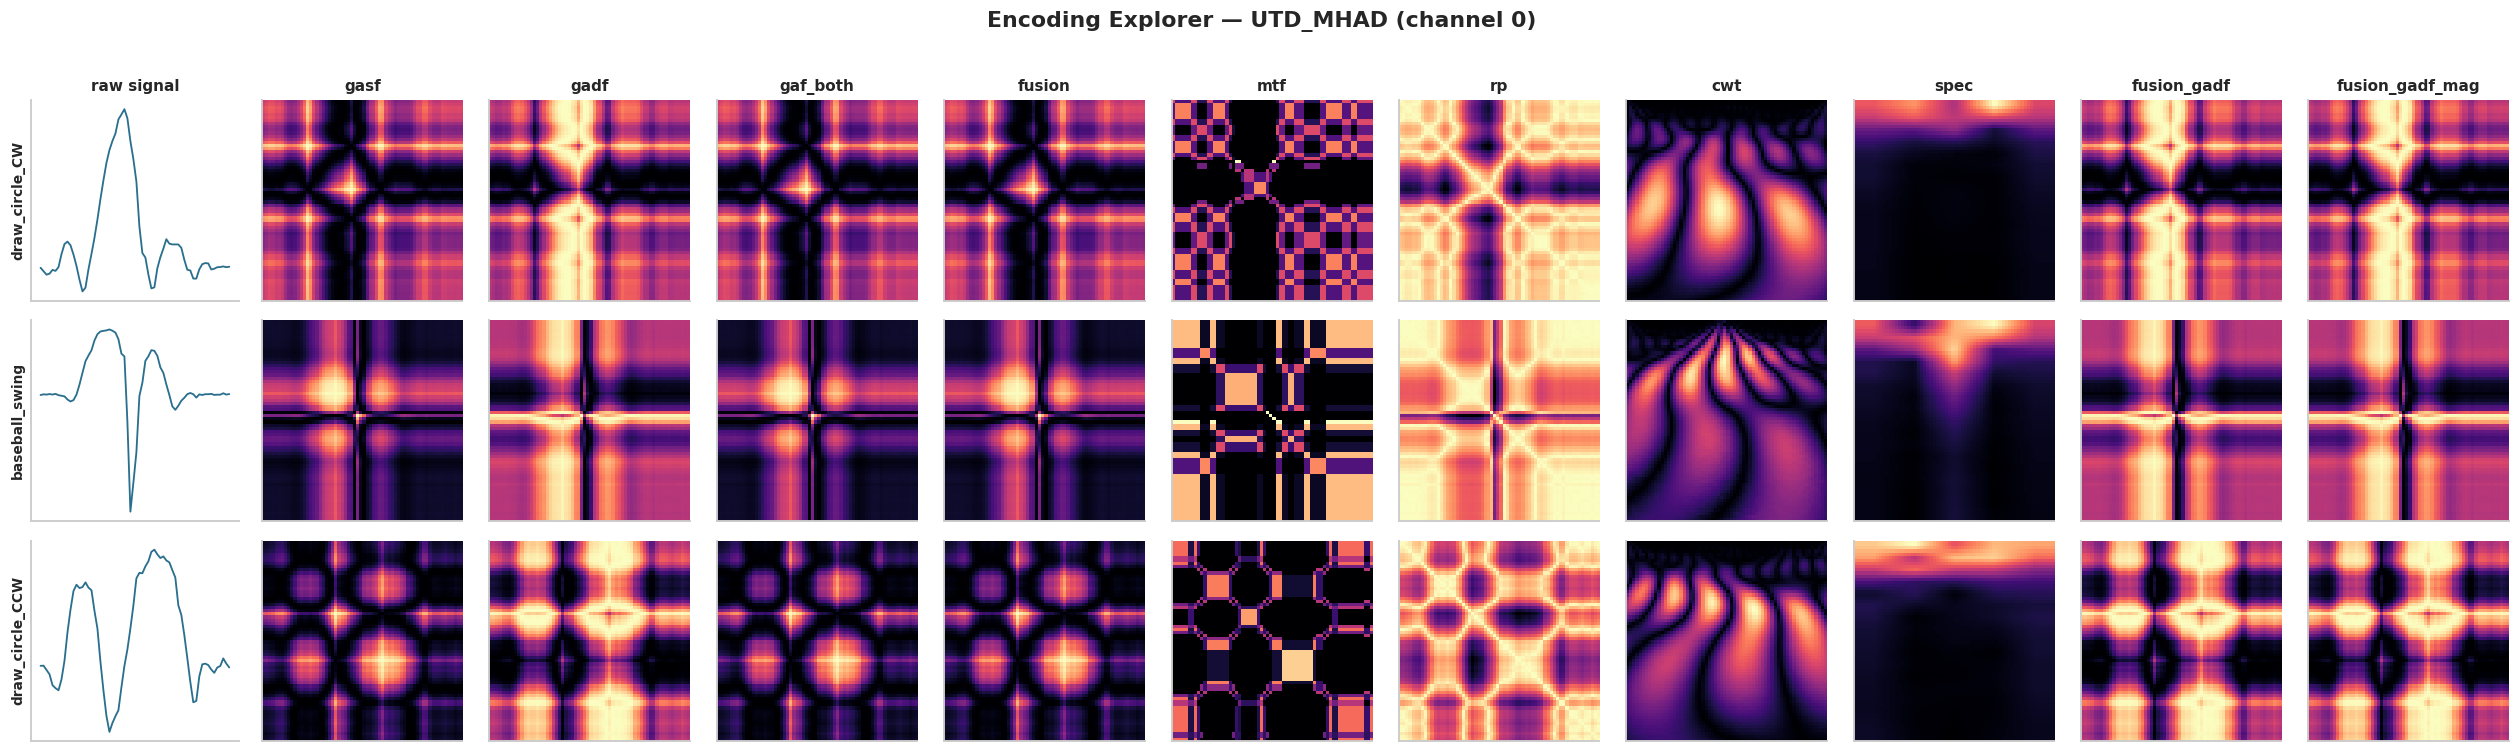

In [10]:
UTD_RESULTS = {}
if CONFIG["RUN_UTD"]:
    X_utd, y_utd, s_utd = load_utd_mhad()
    tr_i, va_i, te_i = utd_subject_split(y_utd, s_utd)          # ΔΙΟΡΘΩΣΗ #1: subject-wise split
    utd_splits_data = ((X_utd[tr_i], y_utd[tr_i]), (X_utd[va_i], y_utd[va_i]), (X_utd[te_i], y_utd[te_i]))
    print(f"UTD-MHAD: train {len(tr_i)} | val {len(va_i)} | test {len(te_i)} "
          f"(train subjects: {sorted(set(s_utd[tr_i]))}, val: {sorted(set(s_utd[va_i]))}, "
          f"test: {sorted(set(s_utd[te_i]))})")
    encoding_gallery(X_utd, y_utd, UTD_CLASS_NAMES, "UTD_MHAD")

In [11]:
if CONFIG["RUN_UTD"]:
    # --- Baselines ---
    UTD_RESULTS["random_forest"] = run_rf_experiment("UTD_MHAD", utd_splits_data, UTD_CLASS_NAMES)
    UTD_RESULTS["cnn1d"]  = run_1d_experiment("UTD_MHAD", "cnn1d",  utd_splits_data, UTD_CLASS_NAMES)
    UTD_RESULTS["bilstm"] = run_1d_experiment("UTD_MHAD", "bilstm", utd_splits_data, UTD_CLASS_NAMES)

=== [UTD_MHAD] baseline_random_forest — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] baseline_cnn1d — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] baseline_bilstm — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===


=== [UTD_MHAD] enc_gasf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_gadf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_gaf_both — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_fusion_gadf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_fusion_gadf_mag — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_mtf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_rp — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_cwt — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_spec — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_fusion — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_gadf_custom_cnn — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_fusion_gadf_custom_cnn — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UTD_MHAD] enc_fusion_gadf_mag_custom_cnn — βρέθηκε ολοκληρ

epoch 1/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep  1/35 | loss 3.401/3.304 | acc   5.0%/  3.7%  * best saved


epoch 2/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep  2/35 | loss 3.222/3.322 | acc   7.4%/  3.7%


...

  ep 34/35 | loss 0.825/1.171 | acc  97.8%/ 87.0%


epoch 35/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep 35/35 | loss 0.822/1.187 | acc  97.5%/ 86.1%


TTA:   0%|          | 0/430 [00:00<?, ?it/s]

    TTA: acc 85.81% | F1 85.08%
   [saved] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_gadf_custom_cnn_v2/metrics.json
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_gadf_custom_cnn_v2/training_curves.png


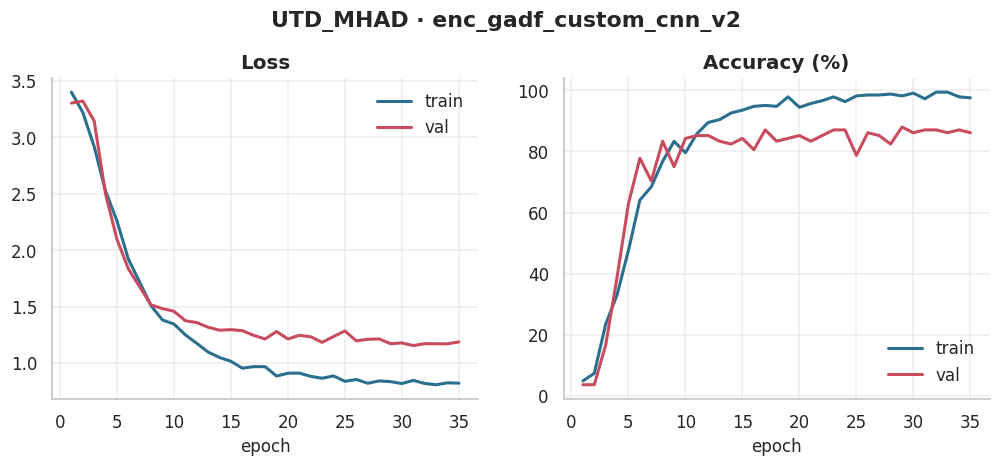

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_gadf_custom_cnn_v2/confusion_matrix.png


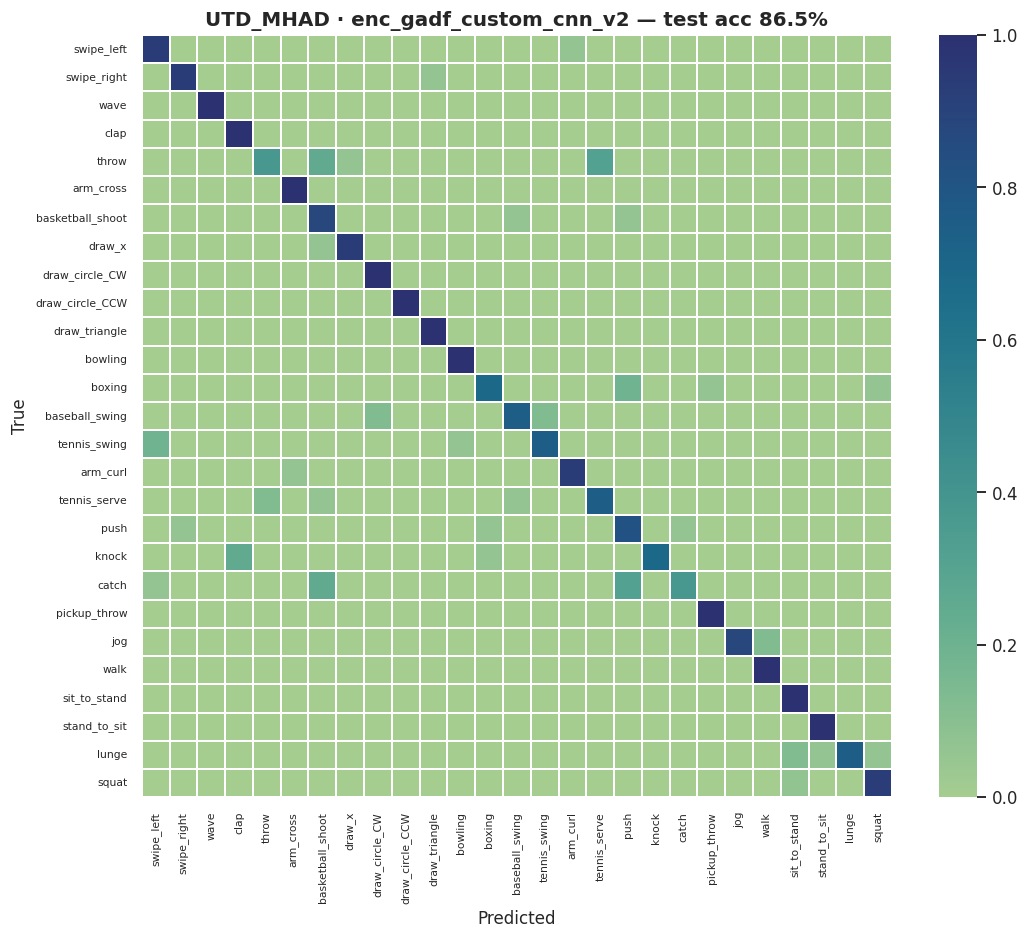

>>> enc_gadf_custom_cnn_v2: test acc 86.51% | F1 85.93%

=== [UTD_MHAD] enc_fusion_gadf_custom_cnn_v2 ===


epoch 1/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep  1/35 | loss 3.449/3.302 | acc   5.9%/  3.7%  * best saved


epoch 2/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep  2/35 | loss 3.151/3.302 | acc  12.7%/  7.4%  * best saved


...

  ep 34/35 | loss 0.835/1.141 | acc  97.2%/ 83.3%


epoch 35/35:   0%|          | 0/11 [00:00<?, ?it/s]

  ep 35/35 | loss 0.827/1.143 | acc  98.5%/ 83.3%


TTA:   0%|          | 0/430 [00:00<?, ?it/s]

    TTA: acc 83.95% | F1 82.91%
   [saved] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_fusion_gadf_custom_cnn_v2/metrics.json
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_fusion_gadf_custom_cnn_v2/training_curves.png


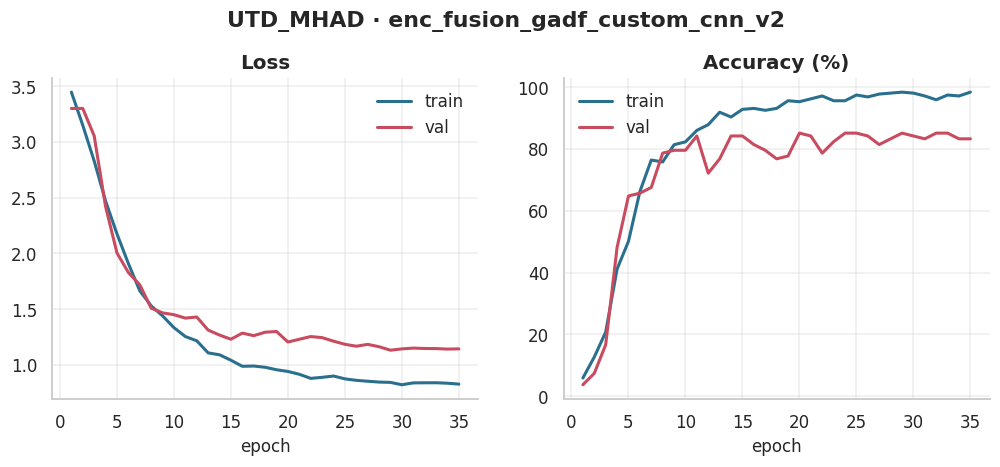

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UTD_MHAD/enc_fusion_gadf_custom_cnn_v2/confusion_matrix.png


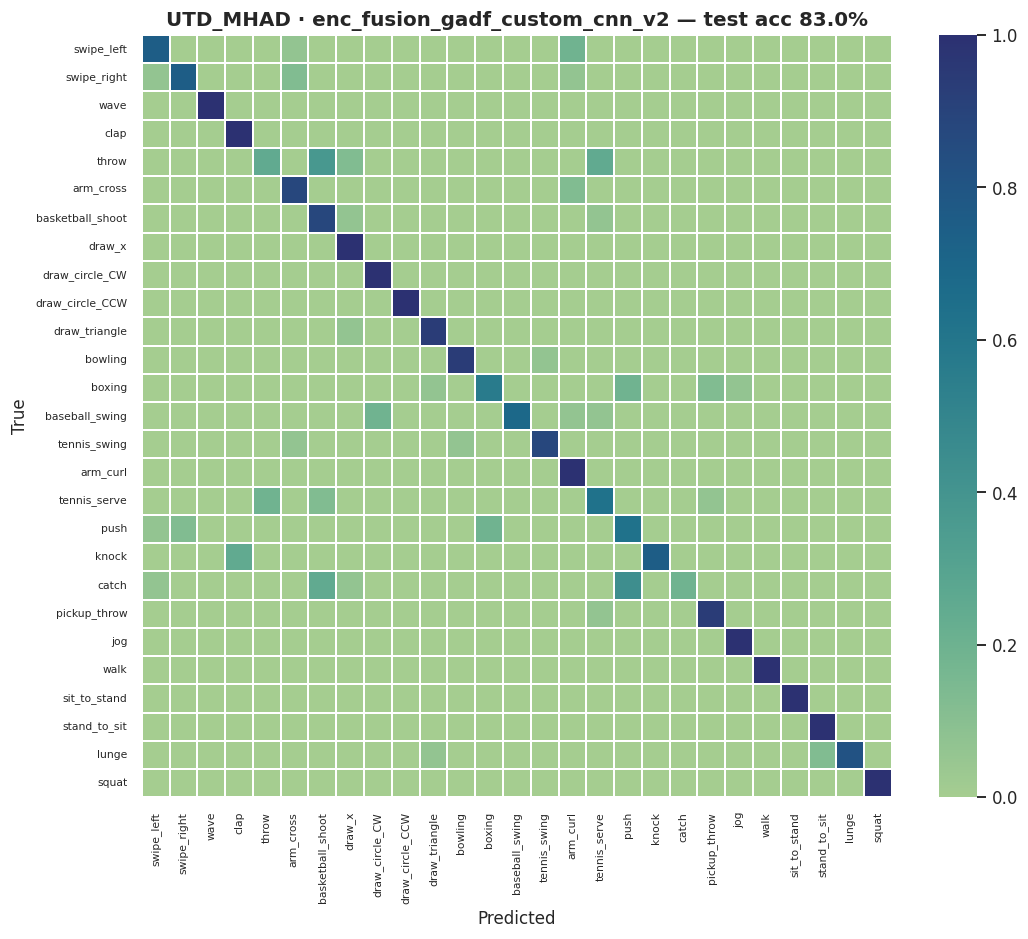

>>> enc_fusion_gadf_custom_cnn_v2: test acc 83.02% | F1 81.97%


In [12]:
if CONFIG["RUN_UTD"]:
    # --- Encoding sweep: ίδιο δίκτυο, διαφορετική κωδικοποίηση (v3: + magnitudes, + TTA) ---
    for enc in ["gasf", "gadf", "gaf_both", "fusion_gadf", "fusion_gadf_mag",
                "mtf", "rp", "cwt", "spec", "fusion"]:
        UTD_RESULTS[enc] = run_encoding_experiment("UTD_MHAD", enc, utd_splits_data,
                                                   UTD_CLASS_NAMES, tta=True)

# --- v4: Custom from-scratch CNN στα κορυφαία encodings (pretrained vs scratch ablation) ---
if CONFIG["RUN_UTD"]:
    for enc in ["gadf", "fusion_gadf", "fusion_gadf_mag"]:
        UTD_RESULTS[enc + "_custom"] = run_encoding_experiment(
            "UTD_MHAD", enc, utd_splits_data, UTD_CLASS_NAMES,
            tta=True, model_name="custom_cnn")

# --- v5: advanced custom CNN (residual + SE + multi-dilation) με warmup ---
if CONFIG["RUN_UTD"]:
    for enc in ["gadf", "fusion_gadf"]:
        UTD_RESULTS[enc + "_custom_v2"] = run_encoding_experiment(
            "UTD_MHAD", enc, utd_splits_data, UTD_CLASS_NAMES,
            tta=True, model_name="custom_cnn_v2", warmup_epochs=3)

# --- v3 προαιρετικό: high-res (128px) run των κορυφαίων encodings ---
RUN_HIGHRES = False        # βάλε True για να τρέξει (4πλάσια pixels → πιο αργό)
if CONFIG["RUN_UTD"] and RUN_HIGHRES:
    for enc in ["fusion_gadf_mag", "fusion_gadf", "gadf"]:
        UTD_RESULTS[enc + "_128"] = run_encoding_experiment(
            "UTD_MHAD", enc, utd_splits_data, UTD_CLASS_NAMES,
            img_size=128, suffix="_128", tta=True)

## 10 · Πειράματα — UCI HAR (2ο dataset, auto-download)
10 299 παράθυρα, 30 subjects, επίσημο subject split — ό,τι χρησιμοποιεί και το paper των Xu et al.
Τρέχουμε τα πιο αντιπροσωπευτικά: 1D-CNN baseline + GADF + MTF + Fusion (η μέθοδός μας).
*Tip:* η 1η εποχή κάθε encoder είναι αργή (χτίζει cache) — μετά πετάει.

UCI HAR: train 6220 | val 1132 | test 2947
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/figures/encoding_gallery_UCI_HAR.png


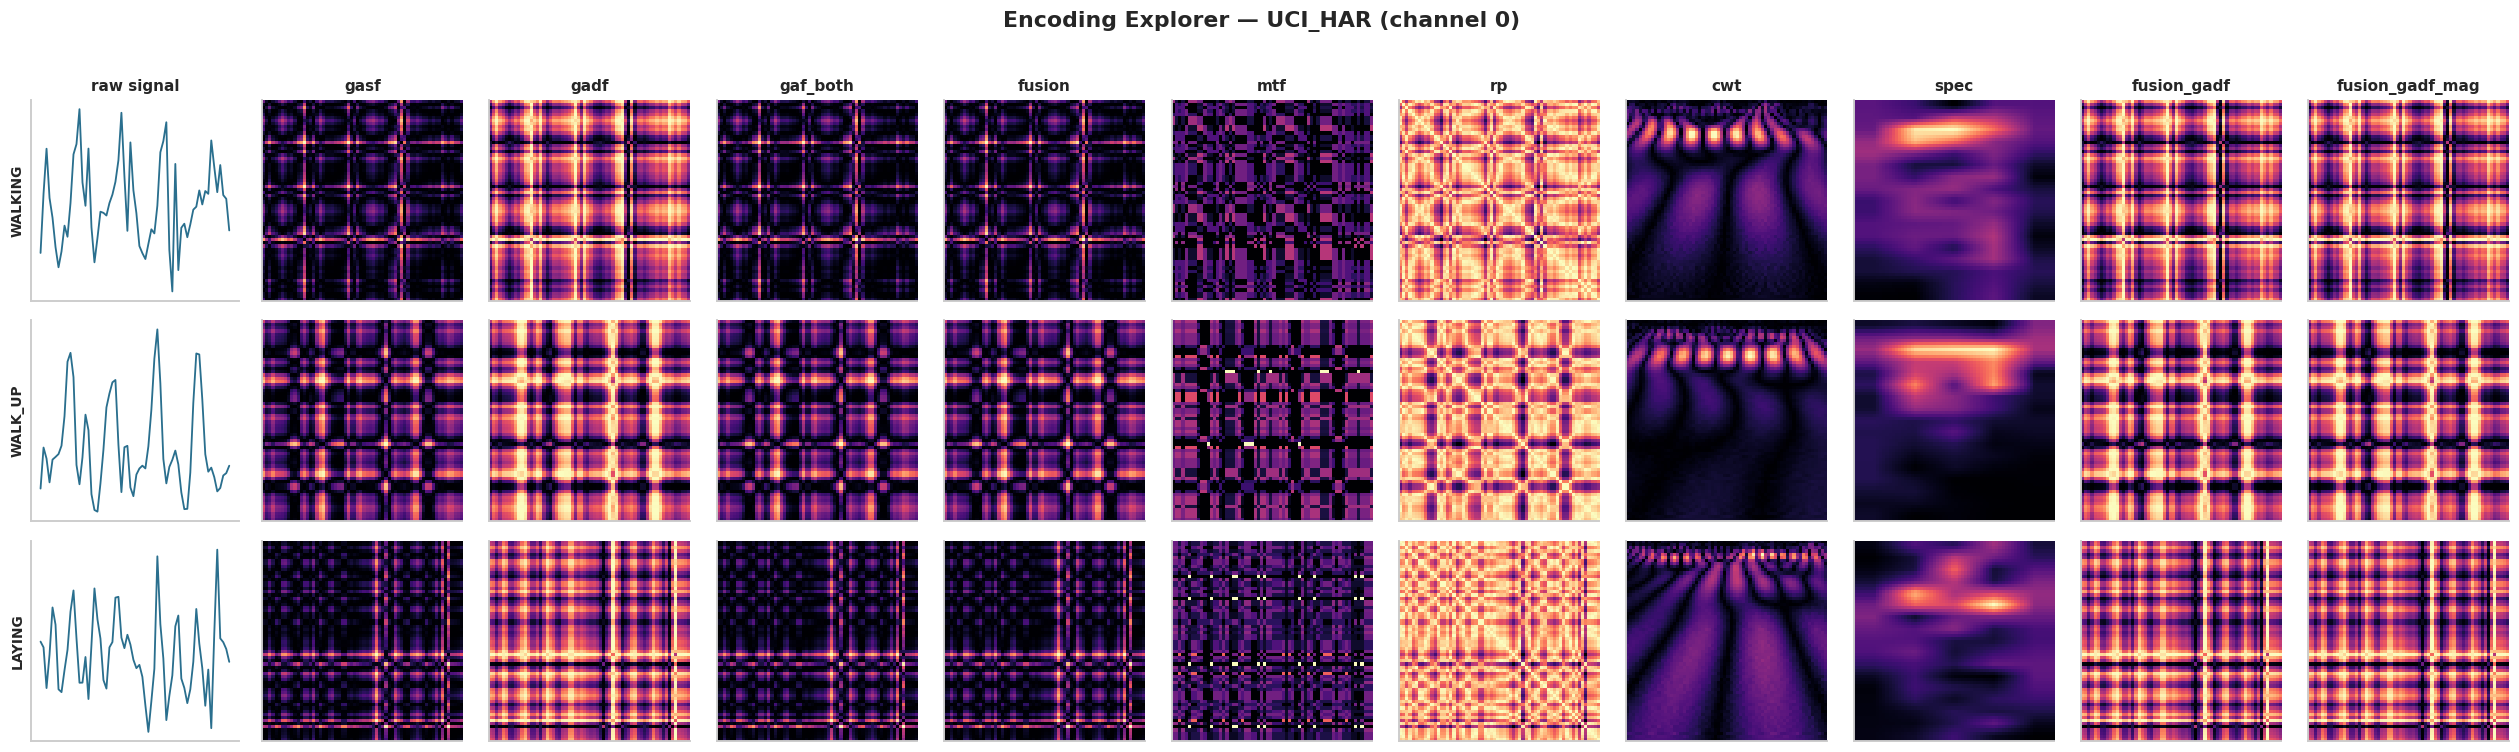

=== [UCI_HAR] baseline_random_forest — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] baseline_cnn1d — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_gadf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_mtf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_fusion — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_fusion_gadf — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_fusion_gadf_mag — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_gadf_custom_cnn — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_fusion_gadf_custom_cnn — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===
=== [UCI_HAR] enc_fusion_gadf_mag_custom_cnn — βρέθηκε ολοκληρωμένο, φορτώθηκε από δίσκο ✓ ===

=== [UCI_HAR] enc_gadf_custom_cnn_v2 ===


epoch 1/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep  1/20 | loss 1.116/0.730 | acc  66.4%/ 88.0%  * best saved


epoch 2/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep  2/20 | loss 0.674/0.626 | acc  90.0%/ 92.4%  * best saved


...

  ep 18/20 | loss 0.437/0.533 | acc 100.0%/ 95.9%  * best saved


epoch 19/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep 19/20 | loss 0.437/0.542 | acc 100.0%/ 95.2%


epoch 20/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep 20/20 | loss 0.437/0.543 | acc 100.0%/ 95.0%
   [saved] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_gadf_custom_cnn_v2/metrics.json
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_gadf_custom_cnn_v2/training_curves.png


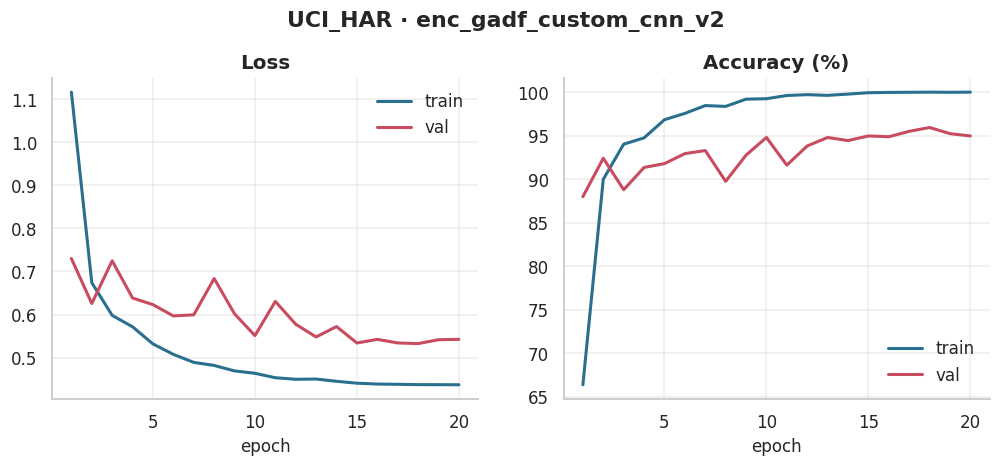

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_gadf_custom_cnn_v2/confusion_matrix.png


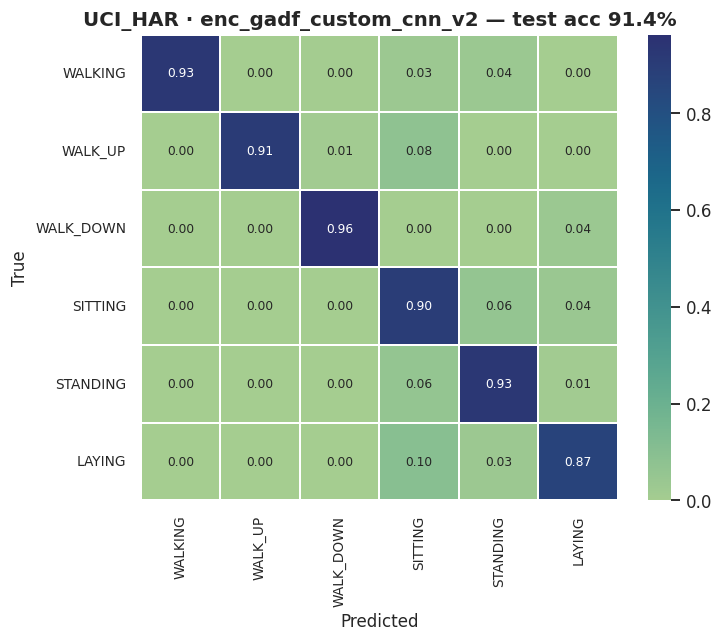

>>> enc_gadf_custom_cnn_v2: test acc 91.45% | F1 91.83%

=== [UCI_HAR] enc_fusion_gadf_custom_cnn_v2 ===


epoch 1/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep  1/20 | loss 1.230/0.815 | acc  59.3%/ 82.3%  * best saved


epoch 2/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep  2/20 | loss 0.737/0.722 | acc  86.3%/ 87.6%  * best saved


...

  ep 18/20 | loss 0.438/0.546 | acc 100.0%/ 94.3%  * best saved


epoch 19/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep 19/20 | loss 0.437/0.553 | acc 100.0%/ 93.6%


epoch 20/20:   0%|          | 0/195 [00:00<?, ?it/s]

  ep 20/20 | loss 0.438/0.553 | acc 100.0%/ 93.6%
   [saved] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_fusion_gadf_custom_cnn_v2/metrics.json
   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_fusion_gadf_custom_cnn_v2/training_curves.png


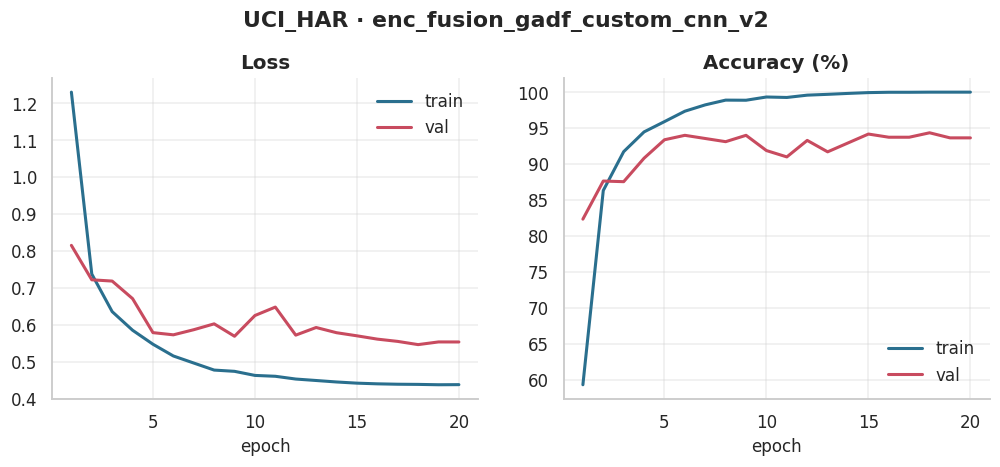

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/UCI_HAR/enc_fusion_gadf_custom_cnn_v2/confusion_matrix.png


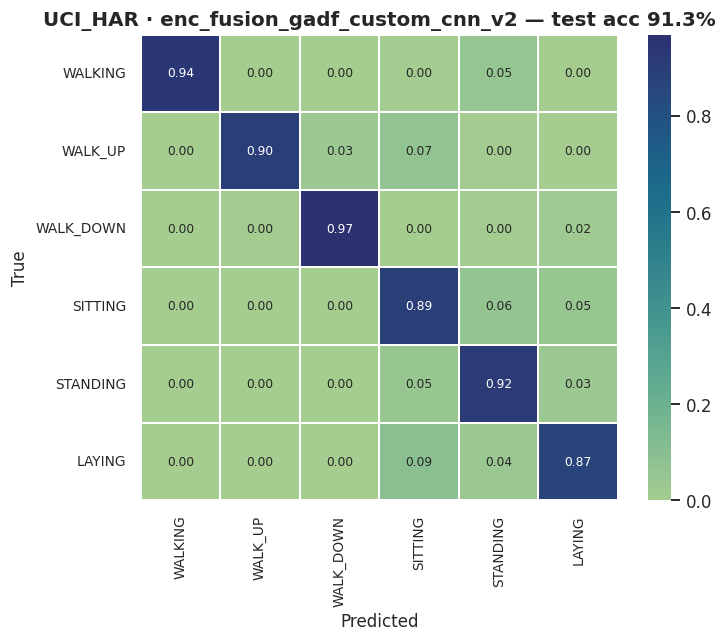

>>> enc_fusion_gadf_custom_cnn_v2: test acc 91.31% | F1 91.66%


In [13]:
UCI_RESULTS = {}
if CONFIG["RUN_UCI"]:
    uci = load_uci_har()
    uci_splits_data = uci_splits(uci)
    (Xtr, ytr), (Xva, yva), (Xte, yte) = uci_splits_data
    print(f"UCI HAR: train {len(ytr)} | val {len(yva)} | test {len(yte)}")
    encoding_gallery(np.concatenate([Xtr, Xte]), np.concatenate([ytr, yte]), UCI_CLASS_NAMES, "UCI_HAR")

    UCI_RESULTS["random_forest"] = run_rf_experiment("UCI_HAR", uci_splits_data, UCI_CLASS_NAMES)
    UCI_RESULTS["cnn1d"] = run_1d_experiment("UCI_HAR", "cnn1d", uci_splits_data, UCI_CLASS_NAMES,
                                             epochs=8 if CONFIG["QUICK_MODE"] else 25)
    for enc in ["gadf", "mtf", "fusion", "fusion_gadf", "fusion_gadf_mag"]:
        UCI_RESULTS[enc] = run_encoding_experiment("UCI_HAR", enc, uci_splits_data, UCI_CLASS_NAMES,
                                                   epochs=6 if CONFIG["QUICK_MODE"] else 20,
                                                   augment=False)   # 21 train subjects → cache αντί για aug

    # v4: custom CNN (με SKIP_IF_DONE, τα ήδη ολοκληρωμένα φορτώνονται από δίσκο)
    for enc in ["gadf", "fusion_gadf", "fusion_gadf_mag"]:
        UCI_RESULTS[enc + "_custom"] = run_encoding_experiment(
            "UCI_HAR", enc, uci_splits_data, UCI_CLASS_NAMES,
            epochs=6 if CONFIG["QUICK_MODE"] else 20, augment=False, model_name="custom_cnn")

    # v5: advanced custom CNN
    for enc in ["gadf", "fusion_gadf"]:
        UCI_RESULTS[enc + "_custom_v2"] = run_encoding_experiment(
            "UCI_HAR", enc, uci_splits_data, UCI_CLASS_NAMES,
            epochs=6 if CONFIG["QUICK_MODE"] else 20, augment=False,
            model_name="custom_cnn_v2", warmup_epochs=3)

## 11 · Πειράματα — WISDM v1.1 (3ο dataset, προαιρετικό, auto-download)
Μόνο accelerometer (3 κανάλια) → η fusion γενικεύεται αυτόματα σε 12 κανάλια.
Ενεργοποίηση: `CONFIG["RUN_WISDM"] = True`.

In [14]:
WISDM_RESULTS = {}
if CONFIG["RUN_WISDM"]:
    Xw, yw, sw = load_wisdm()
    tr_i, va_i, te_i = wisdm_splits(yw, sw)
    wisdm_splits_data = ((Xw[tr_i], yw[tr_i]), (Xw[va_i], yw[va_i]), (Xw[te_i], yw[te_i]))
    print(f"WISDM: train {len(tr_i)} | val {len(va_i)} | test {len(te_i)}")
    encoding_gallery(Xw, yw, WISDM_CLASS_NAMES, "WISDM")

    WISDM_RESULTS["random_forest"] = run_rf_experiment("WISDM", wisdm_splits_data, WISDM_CLASS_NAMES)
    WISDM_RESULTS["cnn1d"] = run_1d_experiment("WISDM", "cnn1d", wisdm_splits_data, WISDM_CLASS_NAMES,
                                               epochs=8 if CONFIG["QUICK_MODE"] else 25)
    for enc in ["gadf", "mtf", "fusion", "fusion_gadf", "fusion_gadf_mag"]:
        WISDM_RESULTS[enc] = run_encoding_experiment("WISDM", enc, wisdm_splits_data, WISDM_CLASS_NAMES,
                                                     epochs=6 if CONFIG["QUICK_MODE"] else 20,
                                                     augment=False)

    # v5: η εκκρεμότητα του Log #3 — custom CNNs στο WISDM
    for enc in ["gadf", "fusion_gadf"]:
        WISDM_RESULTS[enc + "_custom"] = run_encoding_experiment(
            "WISDM", enc, wisdm_splits_data, WISDM_CLASS_NAMES,
            epochs=6 if CONFIG["QUICK_MODE"] else 20, augment=False, model_name="custom_cnn")
        WISDM_RESULTS[enc + "_custom_v2"] = run_encoding_experiment(
            "WISDM", enc, wisdm_splits_data, WISDM_CLASS_NAMES,
            epochs=6 if CONFIG["QUICK_MODE"] else 20, augment=False,
            model_name="custom_cnn_v2", warmup_epochs=3)

## 12 · Συγκεντρωτικά Αποτελέσματα
Σκανάρει **όλα** τα `metrics.json` (και από παλιότερα runs οποιουδήποτε μέλους), φτιάχνει τον τελικό
πίνακα `results/comparison/all_results.csv` και συγκριτικό chart ανά dataset. Αυτό μπαίνει στην αναφορά.

[saved] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/comparison/all_results.csv


,dataset,experiment,type,test_accuracy,tta_accuracy,f1_macro,precision_macro,recall_macro,n_params
24,UCI_HAR,baseline_cnn1d,1D-baseline,92.40,NaN,92.64,92.77,92.57,144838.0
23,UCI_HAR,enc_fusion_gadf_custom_cnn,2D-encoding,92.20,NaN,92.53,92.90,92.43,1178310.0
18,UCI_HAR,enc_gadf_custom_cnn,2D-encoding,91.69,NaN,92.02,92.53,91.87,1176582.0
20,UCI_HAR,enc_fusion_gadf_mag_custom_cnn,2D-encoding,91.55,NaN,91.88,92.12,91.79,1178886.0
29,UCI_HAR,enc_gadf_custom_cnn_v2,2D-encoding,91.45,NaN,91.83,92.38,91.61,1361798.0
26,UCI_HAR,enc_fusion_gadf_custom_cnn_v2,2D-encoding,91.31,NaN,91.66,92.06,91.50,1363526.0
27,UCI_HAR,baseline_random_forest,classical-ML,90.40,NaN,90.46,90.74,90.42,NaN
21,UCI_HAR,enc_fusion_gadf_mag,2D-encoding,78.49,NaN,79.15,80.06,79.10,1663472.0
28,UCI_HAR,enc_fusion_gadf,2D-encoding,78.45,NaN,79.19,79.26,79.15,1663022.0
22,UCI_HAR,enc_gadf,2D-encoding,77.64,NaN,78.43,78.73,78.20,1661672.0


   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/comparison/comparison_UCI_HAR.png


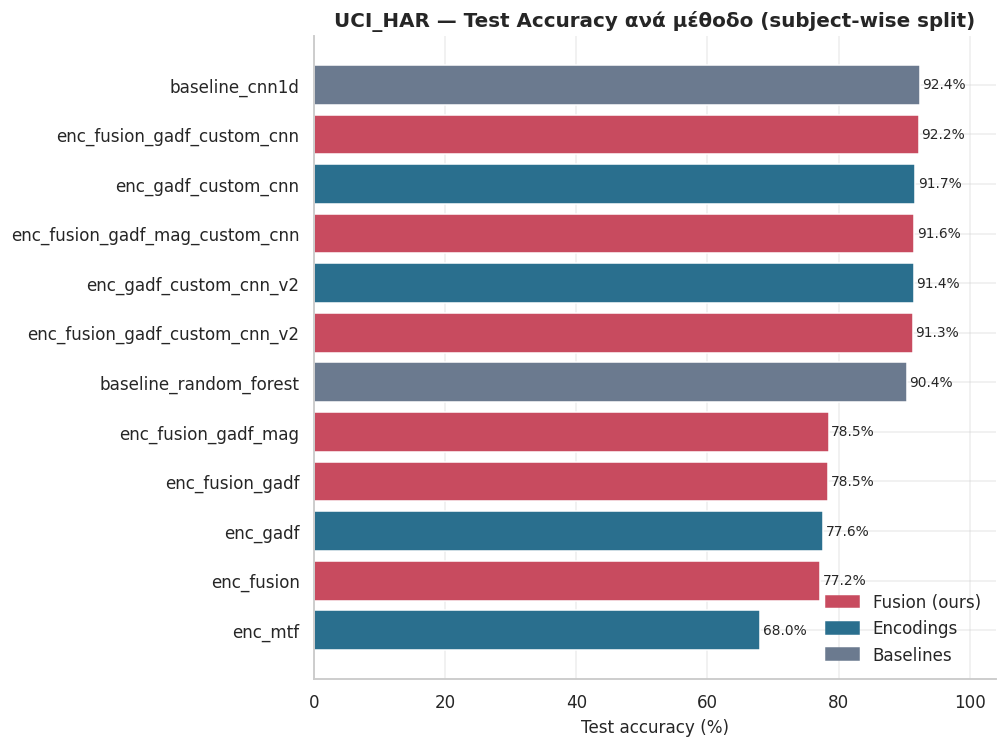

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/comparison/comparison_UTD_MHAD.png


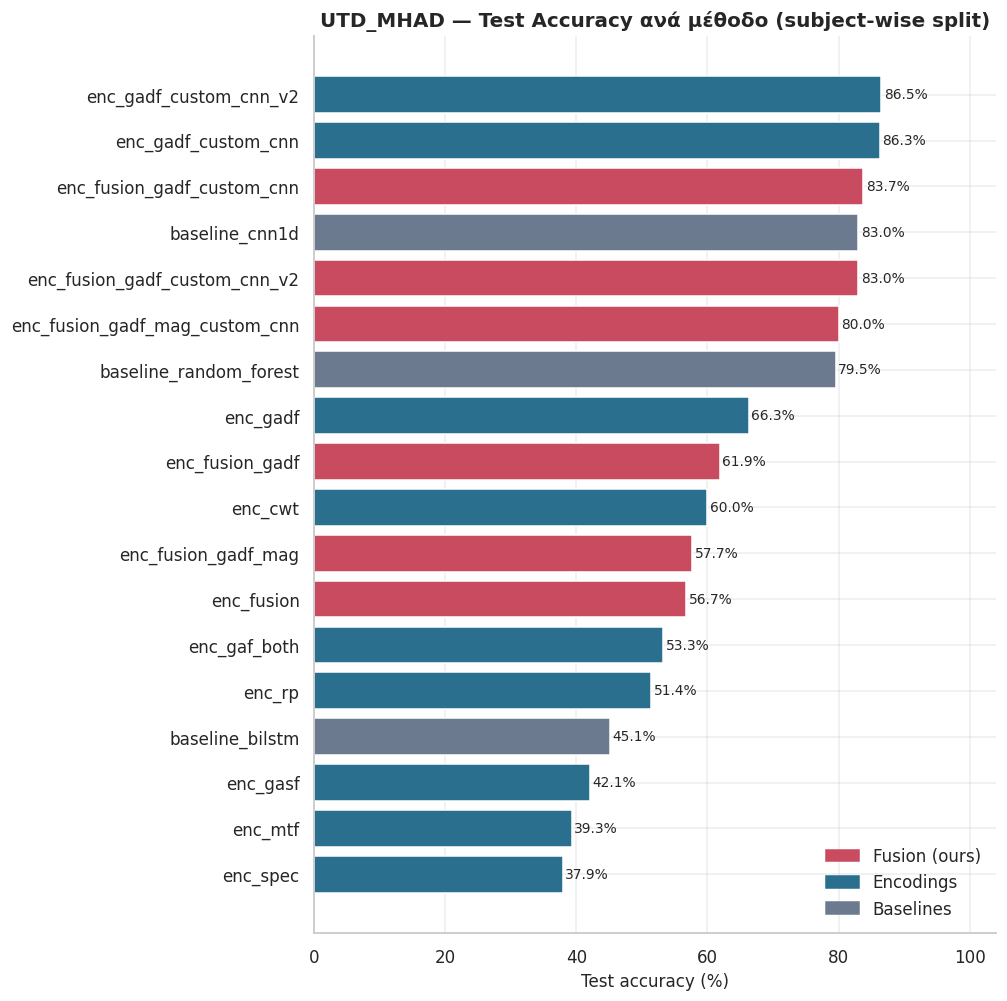

   [saved fig] /Users/panagiotis/Documents/ΣΧΟΛΗ/Ροή Σ/Όραση Υπολογιστών/Bonus_Project/results/comparison/comparison_WISDM.png


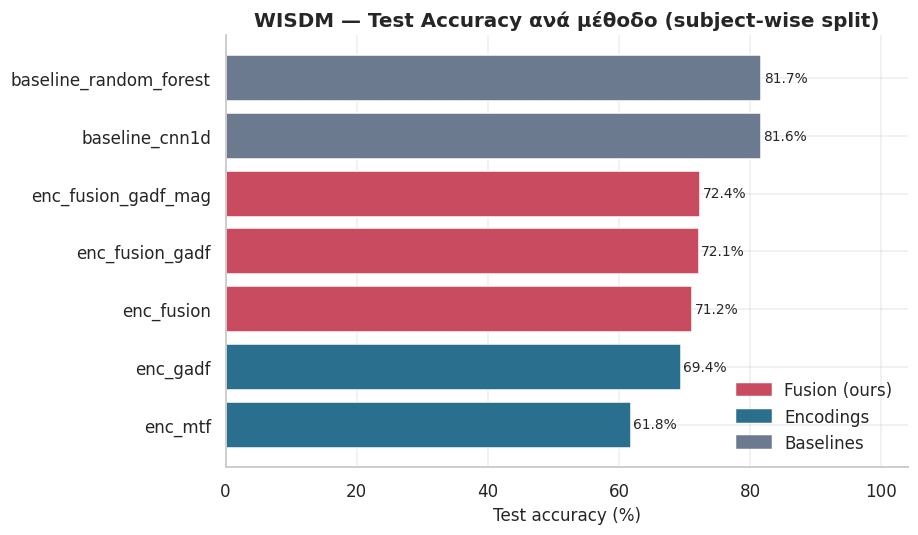

In [15]:
def collect_all_results():
    rows = []
    for mfile in RESULTS_DIR.glob("*/*/metrics.json"):
        m = json.loads(mfile.read_text())
        cfg = json.loads((mfile.parent / "config.json").read_text())
        rows.append({"dataset": mfile.parts[-3], "experiment": mfile.parts[-2],
                     "type": cfg.get("type", "?"), **{k: m.get(k) for k in
                     ("test_accuracy", "tta_accuracy", "f1_macro", "precision_macro",
                      "recall_macro", "n_params")}})
    df = pd.DataFrame(rows).sort_values(["dataset", "test_accuracy"], ascending=[True, False])
    out = RESULTS_DIR / "comparison"; out.mkdir(exist_ok=True)
    df.to_csv(out / "all_results.csv", index=False)
    print(f"[saved] {out/'all_results.csv'}")
    return df

def plot_comparison(df):
    out = RESULTS_DIR / "comparison"
    for ds, g in df.groupby("dataset"):
        g = g.sort_values("test_accuracy")
        colors = [PALETTE[3] if "fusion" in e else (PALETTE[7] if e.startswith("baseline") else PALETTE[0])
                  for e in g.experiment]
        fig, ax = plt.subplots(figsize=(8, 0.5 * len(g) + 1.6))
        bars = ax.barh(g.experiment, g.test_accuracy, color=colors, edgecolor="white")
        for b, v in zip(bars, g.test_accuracy):
            ax.text(v + 0.4, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)
        ax.set(title=f"{ds} — Test Accuracy ανά μέθοδο (subject-wise split)",
               xlabel="Test accuracy (%)", xlim=(0, 104))
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color=PALETTE[3], label="Fusion (ours)"),
                           Patch(color=PALETTE[0], label="Encodings"),
                           Patch(color=PALETTE[7], label="Baselines")], loc="lower right")
        save_fig(fig, out / f"comparison_{ds}.png")

df_all = collect_all_results()
display(df_all.round(2))
plot_comparison(df_all)

## 13 · Οδηγίες για την ομάδα — Πλήρες Pipeline βήμα-βήμα

**Βήμα 0 — Περιβάλλον (μία φορά):**
`pip install torch torchvision numpy scipy scikit-learn pandas matplotlib seaborn tqdm PyWavelets requests`

**Βήμα 1 — Δεδομένα:** Βάλε τον φάκελο `UTD_MHAD_Data/Inertial/` δίπλα στο notebook (όπως ήδη έχετε)
ή στο `data/UTD_MHAD/Inertial/`. UCI HAR & WISDM κατεβαίνουν μόνα τους.

**Βήμα 2 — Ρύθμισε το `CONFIG` (κελί 1):** `QUICK_MODE=True` για πρώτο πέρασμα (~γρήγορο),
`False` για τα τελικά νούμερα. Τα `RUN_*` flags επιλέγουν datasets.

**Βήμα 3 — Run All.** Τα πειράματα τρέχουν σειριακά και τυπώνουν πρόοδο. Αν διακοπεί κάτι,
ξανατρέξε από το κελί που σταμάτησε — caches/encodings δεν ξαναϋπολογίζονται.

**Βήμα 4 — Παραδοτέα:** Όλα στο `results/` και `figures/`:
```
results/
├── UTD_MHAD/
│   ├── baseline_random_forest/   (config, metrics, confusion_matrix.png)
│   ├── baseline_cnn1d/           (+ history.csv, best_model.pth, training_curves.png)
│   ├── enc_gasf/ … enc_fusion/
├── UCI_HAR/ …
└── comparison/
    ├── all_results.csv           ← ο πίνακας της αναφοράς
    └── comparison_<dataset>.png  ← το chart της παρουσίασης
figures/encoding_gallery_<dataset>.png
cache/   (μπορεί να σβηστεί ελεύθερα — ξαναχτίζεται)
```

**Καταμερισμός (πρόταση για 5 άτομα):** καθένας παίρνει ένα flag/μπλοκ (π.χ. UTD encodings,
UCI, WISDM, baselines, report-figures), τρέχει τοπικά και κάνει commit **μόνο** τον φάκελο
`results/` του (τα `best_model.pth` είναι μικρά — ShuffleNet x0.5). Ο πίνακας του κελιού 12
ενοποιεί αυτόματα ό,τι βρει.

**Σημείωση για την αναφορά:** Τα accuracy με subject-wise split θα είναι **χαμηλότερα** από το
~96% του random split — αυτό είναι το σωστό, συγκρίσιμο με τη βιβλιογραφία νούμερο, και η σύγκριση
random-split vs subject-split είναι από μόνη της ωραίο finding για την παρουσίαση.